In [4]:
import os, sys, subprocess, hashlib, json
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from concurrent.futures import ThreadPoolExecutor, as_completed

plt.rcParams.update({"figure.dpi":110, "font.size":11, "axes.grid":True,
                     "grid.alpha":0.3, "figure.figsize":(7,4.5)})
print("Python", sys.version.split()[0], "| numpy", np.__version__, "| pandas", pd.__version__)

Python 3.13.5 | numpy 2.1.0 | pandas 2.2.3


In [5]:
C_SOURCE = r"""/* ============================================================================
 *  sis_lifespan.c
 *
 *  Dinamica SIS sobre redes del configuration model con grado power-law,
 *  simulada con el algoritmo de Gillespie y analizada con el "lifespan method"
 *  (Mata, Boguna, Castellano, Pastor-Satorras, Phys. Rev. E 91, 052117 (2015)).
 *
 *  - delta (tasa de recuperacion) = 1  ->  el control es lambda = lambda/delta.
 *  - Parametro de orden:       Pend(lambda,N)  = P(realizacion endemica).
 *  - Susceptibilidad:          <tau(lambda,N)> = vida media de las NO endemicas.
 *  - Endemica := la cobertura (nodos distintos infectados) alcanza cth*N.
 *
 *  Estructuras de datos clave (todas con insercion/borrado O(1)):
 *    inf_list[]  : nodos infectados (los primeros n_inf).
 *    act[]       : aristas activas, identificadas por su id de arista DIRIGIDA
 *                  (infectado -> susceptible). act_pos[] guarda la posicion de
 *                  cada arista dirigida dentro de act[] para poder borrar en O(1)
 *                  (esto es el "additional data structure" del enunciado).
 *    rev[]       : para cada arista dirigida, el id de su arista inversa.
 *
 *  Compilar:  gcc -O3 -march=native -o sis_lifespan sis_lifespan.c -lm
 * ==========================================================================*/

#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <math.h>
#include <stdint.h>
#include <time.h>

/* ----------------------------- RNG: xoshiro256** --------------------------- */
static uint64_t RNG[4];

static inline uint64_t splitmix64(uint64_t *x) {
    uint64_t z = (*x += 0x9E3779B97F4A7C15ULL);
    z = (z ^ (z >> 30)) * 0xBF58476D1CE4E5B9ULL;
    z = (z ^ (z >> 27)) * 0x94D049BB133111EBULL;
    return z ^ (z >> 31);
}
static void rng_seed(uint64_t seed) {
    uint64_t s = seed ? seed : 0x123456789ABCDEFULL;
    for (int i = 0; i < 4; i++) RNG[i] = splitmix64(&s);
}
static inline uint64_t rotl(const uint64_t x, int k) { return (x << k) | (x >> (64 - k)); }
static inline uint64_t rng_next(void) {
    const uint64_t result = rotl(RNG[1] * 5, 7) * 9;
    const uint64_t t = RNG[1] << 17;
    RNG[2] ^= RNG[0]; RNG[3] ^= RNG[1]; RNG[1] ^= RNG[2]; RNG[0] ^= RNG[3];
    RNG[2] ^= t; RNG[3] = rotl(RNG[3], 45);
    return result;
}
/* doble en [0,1) */
static inline double rng_unit(void) {
    return (double)(rng_next() >> 11) * (1.0 / 9007199254740992.0);
}
/* Multiplicacion 64x64 -> mitad alta, portable (sin __uint128_t).
 * Funciona en MSVC, MinGW y GCC/Linux. */
static inline uint64_t mul_hi64(uint64_t x, uint64_t y) {
    uint64_t xlo = (uint32_t)x, xhi = x >> 32;
    uint64_t ylo = (uint32_t)y, yhi = y >> 32;
    uint64_t ll = xlo * ylo;
    uint64_t lh = xlo * yhi;
    uint64_t hl = xhi * ylo;
    uint64_t hh = xhi * yhi;
    uint64_t mid = (ll >> 32) + (uint32_t)lh + (uint32_t)hl;
    return hh + (lh >> 32) + (hl >> 32) + (mid >> 32);
}

/* entero uniforme sin sesgo en [0,n)  (metodo de Lemire, portable) */
static inline uint64_t rng_below(uint64_t n) {
    uint64_t x  = rng_next();
    uint64_t lo = x * n;          /* mitad baja (desbordamiento intencionado) */
    uint64_t hi = mul_hi64(x, n);
    if (lo < n) {
        uint64_t t = (-n) % n;
        while (lo < t) { x = rng_next(); lo = x * n; hi = mul_hi64(x, n); }
    }
    return hi;
}

/* ----------------------------- Estado global ------------------------------- */
static int      N;            /* numero de nodos                               */
static long     n_edges;      /* aristas no dirigidas                          */
static long     n_dir;        /* aristas dirigidas = 2*n_edges                 */

static long    *adj_start;    /* CSR: offsets, tam N+1                         */
static int     *adj;          /* CSR: vecinos, tam n_dir                       */
static long    *rev;          /* id de la arista dirigida inversa, tam n_dir   */

static uint8_t *state;        /* 0=S, 1=I, tam N                               */
static int     *inf_list;     /* nodos infectados, tam N                       */
static long     n_inf;

static long    *act;          /* aristas activas (id dirigido), tam n_edges    */
static long    *act_pos;      /* posicion en act[] de cada arista dirigida     */
static long     n_act;

static uint8_t *covered;      /* nodo ya infectado alguna vez en la realizacion*/
static int     *touched;      /* lista de nodos cubiertos (para resetear O(cov))*/
static long     n_touch;
static long     cov;          /* cobertura actual                              */

static int     *seed_nodes;   /* nodos candidatos a semilla (grado == kmin)    */
static long     n_seed;

/* --------------------- helpers de listas dinamicas O(1) -------------------- */
static inline void add_active(long de) {
    act[n_act] = de; act_pos[de] = n_act; n_act++;
}
static inline void remove_active(long de) {
    long p = act_pos[de];
    long last = act[--n_act];
    act[p] = last; act_pos[last] = p; act_pos[de] = -1;
}
static inline void add_inf(int v) {
    inf_list[n_inf++] = v; state[v] = 1;
}

/* ---- actualizacion de aristas activas cuando un nodo cambia de estado ----- */
/* v acaba de INFECTARSE (S->I). state[v] ya = 1. */
static inline void update_SI(int v) {
    long a0 = adj_start[v], a1 = adj_start[v + 1];
    for (long de = a0; de < a1; de++) {
        int x = adj[de];
        if (state[x] == 0) add_active(de);        /* v->x pasa a activa        */
        else               remove_active(rev[de]);/* x->v estaba activa: fuera */
    }
}
/* v acaba de RECUPERARSE (I->S). state[v] ya = 0. */
static inline void update_IS(int v) {
    long a0 = adj_start[v], a1 = adj_start[v + 1];
    for (long de = a0; de < a1; de++) {
        int x = adj[de];
        if (state[x] == 0) remove_active(de);      /* v->x estaba activa: fuera */
        else               add_active(rev[de]);    /* x->v pasa a activa        */
    }
}

static int cmp_u64(const void *p, const void *q) {
    uint64_t x = *(const uint64_t *)p, y = *(const uint64_t *)q;
    return (x < y) ? -1 : (x > y) ? 1 : 0;
}

/* =========================== Configuration model ========================== */
/* Muestrea grados ~ k^-gamma en [kmin,kmax], empareja stubs, elimina
 * autoenlaces y multienlaces (grafo simple) y construye la CSR + rev[].       */
static void build_network(int Nn, double gamma, int kmin, int kmax,
                          uint64_t net_seed,
                          double *mean_k, double *mean_k2) {
    rng_seed(net_seed);
    N = Nn;

    /* --- CDF discreta de P(k) ~ k^-gamma --- */
    int K = kmax - kmin + 1;
    double *cdf = (double *)malloc((size_t)K * sizeof(double));
    double acc = 0.0;
    for (int i = 0; i < K; i++) { acc += pow((double)(kmin + i), -gamma); cdf[i] = acc; }
    for (int i = 0; i < K; i++) cdf[i] /= acc;

    int *deg = (int *)malloc((size_t)N * sizeof(int));
    long long stub_sum = 0;
    for (int v = 0; v < N; v++) {
        double u = rng_unit();
        /* busqueda binaria del primer cdf>=u */
        int lo = 0, hi = K - 1;
        while (lo < hi) { int mid = (lo + hi) >> 1; if (cdf[mid] < u) lo = mid + 1; else hi = mid; }
        deg[v] = kmin + lo;
        stub_sum += deg[v];
    }
    free(cdf);
    if (stub_sum & 1LL) { int v = (int)rng_below((uint64_t)N); deg[v]++; stub_sum++; }

    /* --- lista de stubs y barajado de Fisher-Yates --- */
    long long nstub = stub_sum;
    int *stubs = (int *)malloc((size_t)nstub * sizeof(int));
    long long idx = 0;
    for (int v = 0; v < N; v++) for (int j = 0; j < deg[v]; j++) stubs[idx++] = v;
    for (long long i = nstub - 1; i > 0; i--) {
        long long j = (long long)rng_below((uint64_t)(i + 1));
        int tmp = stubs[i]; stubs[i] = stubs[j]; stubs[j] = tmp;
    }
    free(deg);

    /* --- aristas como clave a*N+b (a<b), sin autoenlaces --- */
    long long npair = nstub / 2;
    uint64_t *keys = (uint64_t *)malloc((size_t)npair * sizeof(uint64_t));
    long long cnt = 0;
    for (long long m = 0; m < npair; m++) {
        int a = stubs[2 * m], b = stubs[2 * m + 1];
        if (a == b) continue;                 /* fuera autoenlaces            */
        if (a > b) { int t = a; a = b; b = t; }
        keys[cnt++] = (uint64_t)a * (uint64_t)N + (uint64_t)b;
    }
    free(stubs);

    /* ordenar + unique  -> elimina multienlaces */
    qsort(keys, (size_t)cnt, sizeof(uint64_t), cmp_u64);
    long long E = 0;
    for (long long i = 0; i < cnt; i++) if (i == 0 || keys[i] != keys[i - 1]) keys[E++] = keys[i];
    n_edges = E;
    n_dir   = 2 * E;

    /* --- construir CSR + rev[] --- */
    adj_start = (long *)calloc((size_t)N + 1, sizeof(long));
    for (long long i = 0; i < E; i++) {
        int a = (int)(keys[i] / (uint64_t)N);
        int b = (int)(keys[i] % (uint64_t)N);
        adj_start[a + 1]++; adj_start[b + 1]++;
    }
    for (int v = 0; v < N; v++) adj_start[v + 1] += adj_start[v];

    adj = (int  *)malloc((size_t)n_dir * sizeof(int));
    rev = (long *)malloc((size_t)n_dir * sizeof(long));
    long *cur = (long *)malloc(((size_t)N) * sizeof(long));
    for (int v = 0; v < N; v++) cur[v] = adj_start[v];
    for (long long i = 0; i < E; i++) {
        int a = (int)(keys[i] / (uint64_t)N);
        int b = (int)(keys[i] % (uint64_t)N);
        long pa = cur[a]++; long pb = cur[b]++;
        adj[pa] = b; adj[pb] = a;
        rev[pa] = pb; rev[pb] = pa;
    }
    free(cur);
    free(keys);

    /* --- momentos del grado y lista de semillas (grado == kmin) --- */
    double s1 = 0.0, s2 = 0.0;
    int min_deg = N;
    for (int v = 0; v < N; v++) {
        long d = adj_start[v + 1] - adj_start[v];
        s1 += (double)d; s2 += (double)d * (double)d;
        if ((int)d < min_deg) min_deg = (int)d;
    }
    *mean_k  = s1 / N;
    *mean_k2 = s2 / N;

    int target = kmin;                 /* semilla de grado minimo nominal kmin */
    long c0 = 0;
    for (int v = 0; v < N; v++) if ((adj_start[v + 1] - adj_start[v]) == target) c0++;
    if (c0 == 0) { target = min_deg; for (int v = 0; v < N; v++) if ((adj_start[v+1]-adj_start[v])==target) c0++; }
    seed_nodes = (int *)malloc((size_t)c0 * sizeof(int));
    n_seed = 0;
    for (int v = 0; v < N; v++) if ((adj_start[v + 1] - adj_start[v]) == target) seed_nodes[n_seed++] = v;

    fprintf(stderr,
        "# red construida: N=%d  E=%ld  <k>=%.4f  <k^2>=%.4f  kmin_real=%d  "
        "semillas(grado=%d)=%ld  lambda_c^MF=<k>/<k^2>=%.5f\n",
        N, n_edges, *mean_k, *mean_k2, min_deg, target, n_seed, (*mean_k) / (*mean_k2));
}

/* ============================== una realizacion =========================== */
/* Devuelve 1 si endemica (cobertura>=Cth), 0 si finita. Si finita, *tau.     */
static int run_realization(double lambda, double delta, long Cth, double *tau_out) {
    int v0 = seed_nodes[rng_below((uint64_t)n_seed)];
    double t = 0.0;

    add_inf(v0);
    covered[v0] = 1; touched[n_touch++] = v0; cov = 1;
    update_SI(v0);

    int endemic = 0;
    while (n_inf > 0) {
        double rate_inf = lambda * (double)n_act;
        double rate_rec = delta  * (double)n_inf;
        double ltot = rate_inf + rate_rec;

        /* avance temporal: xi en (0,1] para evitar log(0) */
        double xi = 1.0 - rng_unit();
        t += -log(xi) / ltot;

        if (rng_unit() * ltot < rate_inf) {
            /* --- INFECCION: arista activa al azar -> infectar el extremo S --- */
            long a = (long)rng_below((uint64_t)n_act);
            long de = act[a];
            int w = adj[de];                 /* extremo susceptible             */
            add_inf(w);
            if (!covered[w]) { covered[w] = 1; touched[n_touch++] = w; cov++; }
            update_SI(w);
            if (cov >= Cth) { endemic = 1; break; }
        } else {
            /* --- RECUPERACION: nodo infectado al azar --- */
            long r = (long)rng_below((uint64_t)n_inf);
            int v = inf_list[r];
            inf_list[r] = inf_list[--n_inf];
            state[v] = 0;
            update_IS(v);
        }
    }
    if (!endemic) *tau_out = t;

    /* --- reset O(cobertura): solo lo tocado --- */
    for (long i = 0; i < n_act; i++) act_pos[act[i]] = -1;
    n_act = 0;
    for (long i = 0; i < n_touch; i++) { int v = touched[i]; state[v] = 0; covered[v] = 0; }
    n_touch = 0; n_inf = 0; cov = 0;
    return endemic;
}

/* ================================== main ================================== */
static void usage(const char *p) {
    fprintf(stderr,
      "uso: %s --N <int> --gamma <f> [--kmin 4] [--kmax -1] [--delta 1.0]\n"
      "        [--cth 0.5] --realizations <int>\n"
      "        (--lambda-list \"l1,l2,...\"  |  --lambda-min <f> --lambda-max <f> --lambda-steps <int>)\n"
      "        [--net-seed <u64>] [--dyn-seed <u64>] [--out file.csv] [--save-degrees file]\n"
      "  kmax=-1 -> usa N-1 (sin corte). Para UCM pasar kmax = floor(sqrt(N)).\n", p);
}

int main(int argc, char **argv) {
    int    Nn = 0, kmin = 4, kmax = -1, M = 0, lsteps = 0;
    double gamma = 0.0, delta = 1.0, cth = 0.5, lmin = 0, lmax = 0;
    uint64_t net_seed = 12345ULL, dyn_seed = 67890ULL;
    char  *out = NULL, *llist = NULL, *degfile = NULL;

    for (int i = 1; i < argc; i++) {
        if      (!strcmp(argv[i], "--N"))            Nn = atoi(argv[++i]);
        else if (!strcmp(argv[i], "--gamma"))        gamma = atof(argv[++i]);
        else if (!strcmp(argv[i], "--kmin"))         kmin = atoi(argv[++i]);
        else if (!strcmp(argv[i], "--kmax"))         kmax = atoi(argv[++i]);
        else if (!strcmp(argv[i], "--delta"))        delta = atof(argv[++i]);
        else if (!strcmp(argv[i], "--cth"))          cth = atof(argv[++i]);
        else if (!strcmp(argv[i], "--realizations")) M = atoi(argv[++i]);
        else if (!strcmp(argv[i], "--lambda-list"))  llist = argv[++i];
        else if (!strcmp(argv[i], "--lambda-min"))   lmin = atof(argv[++i]);
        else if (!strcmp(argv[i], "--lambda-max"))   lmax = atof(argv[++i]);
        else if (!strcmp(argv[i], "--lambda-steps")) lsteps = atoi(argv[++i]);
        else if (!strcmp(argv[i], "--net-seed"))     net_seed = strtoull(argv[++i], NULL, 10);
        else if (!strcmp(argv[i], "--dyn-seed"))     dyn_seed = strtoull(argv[++i], NULL, 10);
        else if (!strcmp(argv[i], "--out"))          out = argv[++i];
        else if (!strcmp(argv[i], "--save-degrees")) degfile = argv[++i];
        else { fprintf(stderr, "arg desconocido: %s\n", argv[i]); usage(argv[0]); return 1; }
    }
    if (Nn <= 0 || gamma <= 0 || M <= 0 || (!llist && lsteps <= 0)) { usage(argv[0]); return 1; }
    if (kmax < 0) kmax = Nn - 1;
    if (kmax > Nn - 1) kmax = Nn - 1;

    /* lista de lambdas */
    double *lam = NULL; int nlam = 0;
    if (llist) {
        int cap = 8; lam = malloc(cap * sizeof(double));
        char *s = strdup(llist), *tok = strtok(s, ",");
        while (tok) { if (nlam == cap) { cap *= 2; lam = realloc(lam, cap * sizeof(double)); }
                      lam[nlam++] = atof(tok); tok = strtok(NULL, ","); }
        free(s);
    } else {
        nlam = lsteps; lam = malloc(nlam * sizeof(double));
        for (int i = 0; i < nlam; i++)
            lam[i] = (nlam == 1) ? lmin : lmin + (lmax - lmin) * i / (nlam - 1);
    }

    /* construir red */
    double mean_k, mean_k2;
    build_network(Nn, gamma, kmin, kmax, net_seed, &mean_k, &mean_k2);

    if (degfile) {
        FILE *fd = fopen(degfile, "w");
        for (int v = 0; v < N; v++) fprintf(fd, "%ld\n", adj_start[v + 1] - adj_start[v]);
        fclose(fd);
    }

    /* reservar estructuras de la dinamica (una vez) */
    state    = (uint8_t *)calloc((size_t)N, 1);
    inf_list = (int     *)malloc((size_t)N * sizeof(int));
    covered  = (uint8_t *)calloc((size_t)N, 1);
    touched  = (int     *)malloc((size_t)N * sizeof(int));
    act      = (long    *)malloc((size_t)n_edges * sizeof(long));
    act_pos  = (long    *)malloc((size_t)n_dir   * sizeof(long));
    for (long i = 0; i < n_dir; i++) act_pos[i] = -1;
    n_inf = n_act = n_touch = cov = 0;

    long Cth = (long)(cth * (double)N);
    if (Cth < 1) Cth = 1;

    rng_seed(dyn_seed);

    FILE *f = out ? fopen(out, "w") : stdout;
    fprintf(f, "# SIS lifespan  N=%d gamma=%.3f kmin=%d kmax=%d delta=%.3f cth=%.3f "
               "realizations=%d net_seed=%llu dyn_seed=%llu\n",
               N, gamma, kmin, kmax, delta, cth, M,
               (unsigned long long)net_seed, (unsigned long long)dyn_seed);
    fprintf(f, "# E=%ld mean_k=%.6f mean_k2=%.6f lambda_c_MF=%.6f Cth=%ld\n",
               n_edges, mean_k, mean_k2, mean_k / mean_k2, Cth);
    fprintf(f, "lambda,p_end,p_end_err,tau_mean,tau_err,tau2_mean,tau2_err,n_finite,n_endemic,n_real,mean_k,mean_k2\n");

    for (int il = 0; il < nlam; il++) {
        double lambda = lam[il];
        long n_end = 0, n_fin = 0;
        double S1 = 0, S2 = 0, S3 = 0, S4 = 0;   /* sumas de potencias de tau */
        for (int r = 0; r < M; r++) {
            double tau = 0.0;
            int e = run_realization(lambda, delta, Cth, &tau);
            if (e) n_end++;
            else { n_fin++; double t2 = tau * tau; S1 += tau; S2 += t2; S3 += t2 * tau; S4 += t2 * t2; }
        }
        double p = (double)n_end / (double)M;
        double p_err = sqrt(p * (1.0 - p) / (double)M);
        double nf = (double)n_fin;
        double tau_mean  = (n_fin > 0) ? S1 / nf : 0.0;
        double tau2_mean = (n_fin > 0) ? S2 / nf : 0.0;
        double tau_err   = (n_fin > 1) ? sqrt((S2 / nf - tau_mean  * tau_mean ) / nf) : 0.0;
        double tau2_err  = (n_fin > 1) ? sqrt((S4 / nf - tau2_mean * tau2_mean) / nf) : 0.0;
        fprintf(f, "%.8g,%.8g,%.8g,%.8g,%.8g,%.8g,%.8g,%ld,%ld,%d,%.6f,%.6f\n",
                lambda, p, p_err, tau_mean, tau_err, tau2_mean, tau2_err,
                n_fin, n_end, M, mean_k, mean_k2);
        fflush(f);
        fprintf(stderr, "  lambda=%.5f  Pend=%.4f  <tau>=%.3f  <tau2>=%.3f  (fin=%ld end=%ld)\n",
                lambda, p, tau_mean, tau2_mean, n_fin, n_end);
    }
    if (out) fclose(f);
    return 0;
}
"""

with open("sis_lifespan.c","w") as f:
    f.write(C_SOURCE)
print("Escrito sis_lifespan.c (%d líneas)" % len(C_SOURCE.splitlines()))

Escrito sis_lifespan.c (411 líneas)


In [3]:
conda install -c msys2 m2w64-gcc


Note: you may need to restart the kernel to use updated packages.


"conda" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [4]:
import os
print(os.getcwd())

c:\Users\34633\Documents\master\complex networks


In [5]:
import os
print(os.getcwd())
print(os.listdir("."))

c:\Users\34633\Documents\master\complex networks
['.ipynb_checkpoints', '2_ComplexSystems_Intro_networks.pdf', 'clustering_coefficient.png', 'communities.png', 'coordenadas_ciudades.json', 'degree_histogram.png', 'degree_list.txt', 'figs', 'GillespieSIS.pdf', 'mapa_eurorrutas.html', 'network.ipynb', 'networks', 'percolation.pdf', 'simulation_results', 'sis_lifespan.c', 'SIS_lifespan.ipynb', 'sis_lifespan_gamma2.5.png', 'sis_lifespan_gamma3.5.png', 'sis_results', 'small world networks.pdf', 'subelj_euroroad', 'Untitled-2.ipynb']


In [6]:
import subprocess
r = subprocess.run(
    "gcc -O3 -Wall -o sis_lifespan.exe sis_lifespan.c",
    shell=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)
print("RETURN CODE:", r.returncode)
print("OUTPUT:", r.stdout)

RETURN CODE: 1
OUTPUT: "gcc" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.



In [6]:
import platform
BIN = "./sis_lifespan"
if platform.system() == "Windows":
    BIN = ".\\sis_lifespan.exe"

for flags in [["-O3", "-march=native", "-Wall"], ["-O3", "-Wall"]]:
    try:
        r = subprocess.run(
            ["gcc", *flags, "-o", BIN.lstrip("./\\"), "sis_lifespan.c", "-lm"],
            check=True, capture_output=True, text=True)
        print("Compilado OK ->", BIN, "(flags:", " ".join(flags), ")")
        break
    except subprocess.CalledProcessError as e:
        if flags == ["-O3", "-Wall"]:
            print("ERROR de compilación:")
            print(e.stderr)
            raise

import tempfile, os
with tempfile.NamedTemporaryFile(suffix=".csv", delete=False) as tmp:
    tmpf = tmp.name
try:
    subprocess.run([BIN, "--N","2000","--gamma","3.5","--kmin","4","--kmax","44",
                    "--cth","0.5","--realizations","2000","--net-seed","1","--dyn-seed","1",
                    "--lambda-list","0.1,0.15,0.2","--out", tmpf],
                   capture_output=True, text=True, check=True)
    print(pd.read_csv(tmpf, comment='#')[["lambda","p_end","tau_mean","tau2_mean"]])
finally:
    os.unlink(tmpf)

Compilado OK -> .\sis_lifespan.exe (flags: -O3 -march=native -Wall )
   lambda   p_end  tau_mean  tau2_mean
0    0.10  0.0000  1.355668   4.950859
1    0.15  0.0175  2.201583  31.873035
2    0.20  0.1185  1.327830   5.168257


In [7]:
PROFILE = "demo"

CFG = {
    "demo": dict(

        sizes      = [10_000, 30_000, 50_000, 100_000, 300_000, 500_000,  1_000_000],
        realizations = 50_000,
        n_net      = 3,
        grids = {
            3.5: np.round(np.linspace(0.085, 0.13, 28), 5),
            2.5: np.round(np.linspace(0.010, 0.065, 28), 5),
        },
    ),
    "full": dict(
        sizes      = [10_000, 30_000, 50_000, 100_000, 300_000, 500_000, 1_000_000],
        realizations = 100_000,
        n_net      = 3,
        grids = {
            3.5: np.round(np.linspace(0.095, 0.150, 28), 5),
            2.5: np.round(np.linspace(0.010, 0.100, 31), 5),
        },
    ),
}[PROFILE]

CFG.update(dict(
    gammas   = [2.5, 3.5],
    kmin     = 4,
    cth      = 0.5,
    kmax_fn  = lambda N: int(np.sqrt(N)),
    base_net_seed = 1000,
    base_dyn_seed = 1,
    workers  = os.cpu_count(),
    cache    = True,
))
print(f"Perfil={PROFILE}  tamaños={CFG['sizes']}  realizaciones={CFG['realizations']}  "
      f"n_net={CFG['n_net']}  workers={CFG['workers']}")

Perfil=demo  tamaños=[10000, 30000, 50000, 100000, 300000, 500000, 1000000]  realizaciones=50000  n_net=3  workers=12


In [8]:
RESDIR = "resultados"; os.makedirs(RESDIR, exist_ok=True)

def _key(**kw):
    return hashlib.md5(json.dumps(kw, sort_keys=True, default=str).encode()).hexdigest()[:16]

def run_c(N, gamma, lambdas, M, cth, kmin, kmax, net_seed, dyn_seed, save_degrees=None):
    import tempfile, os as _os
    lam_str = ",".join(f"{x:.6g}" for x in lambdas)
    with tempfile.NamedTemporaryFile(suffix=".csv", delete=False) as tmp:
        tmpf = tmp.name
    try:
        cmd = [BIN, "--N", str(N), "--gamma", str(gamma), "--kmin", str(kmin),
               "--kmax", str(kmax), "--cth", str(cth), "--realizations", str(M),
               "--net-seed", str(net_seed), "--dyn-seed", str(dyn_seed),
               "--lambda-list", lam_str, "--out", tmpf]
        if save_degrees: cmd += ["--save-degrees", save_degrees]
        subprocess.run(cmd, capture_output=True, text=True, check=True)
        return pd.read_csv(tmpf, comment='#')
    finally:
        try: _os.unlink(tmpf)
        except: pass

def _average_networks(per_net):
    if len(per_net) == 1:
        return per_net[0].reset_index(drop=True)
    base = per_net[0]['lambda'].values
    P    = np.array([d['p_end'].values     for d in per_net])
    NF   = np.array([d['n_finite'].values  for d in per_net], float)
    TAU  = np.array([d['tau_mean'].values  for d in per_net])
    TAU2 = np.array([d['tau2_mean'].values for d in per_net])
    NE   = np.array([d['n_endemic'].values for d in per_net], float)
    NR   = np.array([d['n_real'].values    for d in per_net], float)
    p_end = P.mean(0)
    p_err = np.sqrt(np.clip(p_end*(1-p_end),0,None)/NR.sum(0))
    w = NF.sum(0); w[w == 0] = 1.0
    tau  = (TAU*NF).sum(0)/w
    tau2 = (TAU2*NF).sum(0)/w
    n = len(per_net)
    tau_err  = TAU.std(0, ddof=1)/np.sqrt(n)
    tau2_err = TAU2.std(0, ddof=1)/np.sqrt(n)
    return pd.DataFrame({'lambda':base, 'p_end':p_end, 'p_end_err':p_err,
        'tau_mean':tau, 'tau_err':tau_err, 'tau2_mean':tau2, 'tau2_err':tau2_err,
        'n_finite':NF.sum(0), 'n_endemic':NE.sum(0), 'n_real':NR.sum(0),
        'mean_k':np.array([d['mean_k'].values for d in per_net]).mean(0),
        'mean_k2':np.array([d['mean_k2'].values for d in per_net]).mean(0)})

def sweep(gamma, N, lambdas, M=None, cth=None, kmin=None, kmax=None,
          n_net=None, tag="", verbose=True):
    M     = M     if M     is not None else CFG["realizations"]
    cth   = cth   if cth   is not None else CFG["cth"]
    kmin  = kmin  if kmin  is not None else CFG["kmin"]
    kmax  = kmax  if kmax  is not None else CFG["kmax_fn"](N)
    n_net = n_net if n_net is not None else CFG["n_net"]
    lambdas = [float(x) for x in lambdas]
    key  = _key(g=gamma, N=N, lam=[round(x,6) for x in lambdas], M=M, cth=cth,
                kmin=kmin, kmax=kmax, n_net=n_net, tag=tag)
    path = os.path.join(RESDIR, f"sweep_{key}.csv")
    if CFG["cache"] and os.path.exists(path):
        return pd.read_csv(path)
    workers = CFG["workers"]
    n_chunks = min(len(lambdas), max(1, workers))
    chunks = [lambdas[i::n_chunks] for i in range(n_chunks)]
    chunks = [c for c in chunks if c]
    tasks = []
    for inet in range(n_net):
        ns = CFG["base_net_seed"] + inet
        for ic, ch in enumerate(chunks):
            ds = CFG["base_dyn_seed"] + inet*1000 + ic
            tasks.append((inet, ns, ds, ch))
    results = {}
    with ThreadPoolExecutor(max_workers=workers) as ex:
        futs = {ex.submit(run_c, N, gamma, ch, M, cth, kmin, kmax, ns, ds): inet
                for (inet, ns, ds, ch) in tasks}
        for f in as_completed(futs):
            results.setdefault(futs[f], []).append(f.result())
    per_net = [pd.concat(dfs).sort_values("lambda").reset_index(drop=True)
               for dfs in results.values()]
    out = _average_networks(per_net)
    if CFG["cache"]:
        out.to_csv(path, index=False)
    if verbose:
        print(f"  γ={gamma}  N={N:>8d}  <k>={out['mean_k'].iloc[0]:.3f}  "
              f"<k²>={out['mean_k2'].iloc[0]:.2f}  λc_MF≈{out['mean_k'].iloc[0]/out['mean_k2'].iloc[0]:.4f}")
    return out

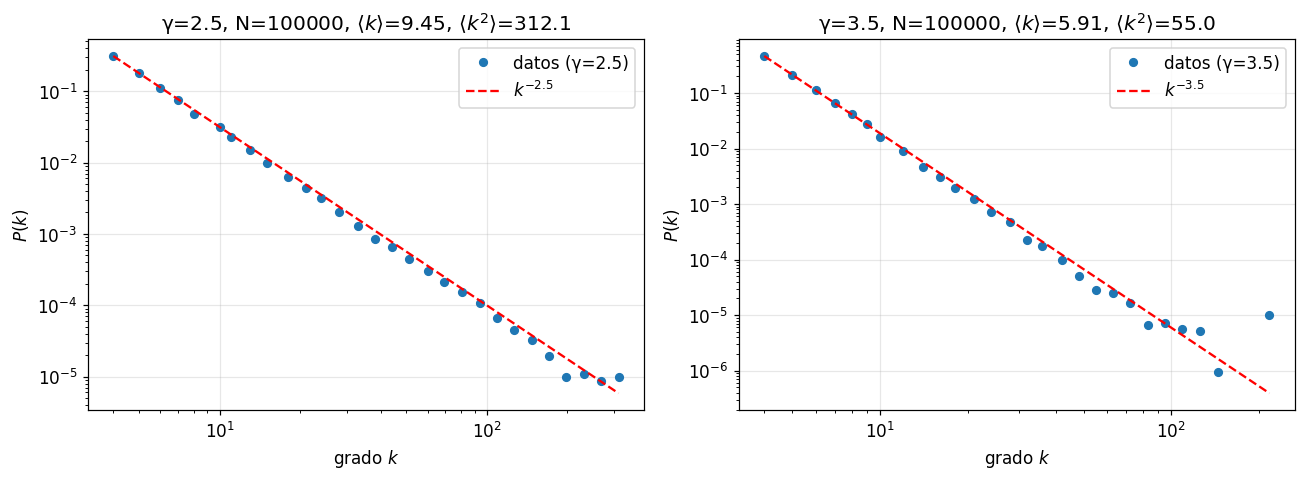

In [9]:
def degree_sequence(gamma, N, net_seed=1000, kmax=None):
    kmax = kmax if kmax is not None else CFG["kmax_fn"](N)
    fn = os.path.join(RESDIR, f"deg_g{gamma}_N{N}_s{net_seed}.txt")
    run_c(N, gamma, [0.05], M=1, cth=CFG["cth"], kmin=CFG["kmin"], kmax=kmax,
          net_seed=net_seed, dyn_seed=1, save_degrees=fn)
    return np.loadtxt(fn, dtype=int)

N_demo = CFG["sizes"][min(3, len(CFG["sizes"])-1)]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, g in zip(axes, CFG["gammas"]):
    deg = degree_sequence(g, N_demo)
    kmax = deg.max()
    bins = np.unique(np.round(np.logspace(np.log10(CFG["kmin"]),
                                          np.log10(kmax), 30)).astype(int))
    h, edges = np.histogram(deg, bins=np.append(bins, bins[-1]+1), density=True)
    centers = bins.astype(float)
    m = h > 0
    ax.loglog(centers[m], h[m], 'o', ms=5, label=f"datos (γ={g})")
    kk = np.logspace(np.log10(CFG["kmin"]), np.log10(kmax), 50)
    ref = kk**(-g); ref *= h[m][0]/ref[np.argmin(abs(kk-centers[m][0]))]
    ax.loglog(kk, ref, 'r--', label=fr"$k^{{-{g}}}$")
    ax.set(xlabel="grado $k$", ylabel="$P(k)$",
           title=fr"γ={g}, N={N_demo}, $\langle k\rangle$={deg.mean():.2f}, $\langle k^2\rangle$={ (deg**2).mean():.1f}")
    ax.legend()
plt.tight_layout(); plt.show()

In [10]:
RES = {g: {} for g in CFG["gammas"]}
for g in CFG["gammas"]:
    print(f"=== γ = {g} ===")
    grid = CFG["grids"][g]
    for N in CFG["sizes"]:
        RES[g][N] = sweep(g, N, grid)
print("\nListo. Ejemplo (γ=3.5, primer tamaño):")
display(RES[3.5][CFG["sizes"][0]].head())

=== γ = 2.5 ===
=== γ = 3.5 ===

Listo. Ejemplo (γ=3.5, primer tamaño):


,lambda,p_end,p_end_err,tau_mean,tau_err,tau2_mean,tau2_err,n_finite,n_endemic,n_real,mean_k,mean_k2
0,0.08500,0.0,0.0,1.319268,0.004021,4.618760,0.065643,150000.0,0.0,150000.0,5.895867,51.0476
1,0.08667,0.0,0.0,1.336070,0.004541,4.853166,0.040141,150000.0,0.0,150000.0,5.895867,51.0476
2,0.08833,0.0,0.0,1.339414,0.003811,4.931054,0.046791,150000.0,0.0,150000.0,5.895867,51.0476
3,0.09000,0.0,0.0,1.355758,0.012513,5.170183,0.146332,150000.0,0.0,150000.0,5.895867,51.0476
4,0.09167,0.0,0.0,1.376606,0.003276,5.390121,0.053941,150000.0,0.0,150000.0,5.895867,51.0476


In [11]:
import os, glob, hashlib, json
import numpy as np, pandas as pd

def reload_from_cache():
    RES = {g: {} for g in CFG["gammas"]}
    missing = []
    for g in CFG["gammas"]:
        grid = CFG["grids"][g]
        for N in CFG["sizes"]:
            kmax  = CFG["kmax_fn"](N)
            lams  = [round(float(x), 6) for x in grid]
            key   = hashlib.md5(json.dumps(
                        dict(g=g, N=N, lam=lams,
                             M=CFG["realizations"], cth=CFG["cth"],
                             kmin=CFG["kmin"], kmax=kmax,
                             n_net=CFG["n_net"], tag=""),
                        sort_keys=True, default=str).encode()
                    ).hexdigest()[:16]
            path  = os.path.join(RESDIR, f"sweep_{key}.csv")
            if os.path.exists(path):
                RES[g][N] = pd.read_csv(path)
            else:
                missing.append((g, N, path))
    if missing:
        print("⚠️  Faltan estos ficheros en caché (habrá que recalcular):")
        for g, N, p in missing:
            print(f"   γ={g}  N={N}  →  {os.path.basename(p)}")
    else:
        print("✓ Todos los resultados cargados desde caché:")
        for g in CFG["gammas"]:
            for N in CFG["sizes"]:
                d = RES[g][N]
                print(f"   γ={g}  N={N:>8d}  "
                      f"<k>={d['mean_k'].iloc[0]:.3f}  "
                      f"puntos λ={len(d)}")
    return RES

RES = reload_from_cache()

✓ Todos los resultados cargados desde caché:
   γ=2.5  N=   10000  <k>=8.676  puntos λ=28
   γ=2.5  N=   30000  <k>=9.095  puntos λ=28
   γ=2.5  N=   50000  <k>=9.261  puntos λ=28
   γ=2.5  N=  100000  <k>=9.451  puntos λ=28
   γ=2.5  N=  300000  <k>=9.717  puntos λ=28
   γ=2.5  N=  500000  <k>=9.835  puntos λ=28
   γ=2.5  N= 1000000  <k>=9.954  puntos λ=28
   γ=3.5  N=   10000  <k>=5.896  puntos λ=28
   γ=3.5  N=   30000  <k>=5.904  puntos λ=28
   γ=3.5  N=   50000  <k>=5.910  puntos λ=28
   γ=3.5  N=  100000  <k>=5.910  puntos λ=28
   γ=3.5  N=  300000  <k>=5.915  puntos λ=28
   γ=3.5  N=  500000  <k>=5.921  puntos λ=28
   γ=3.5  N= 1000000  <k>=5.923  puntos λ=28


In [20]:
extra_nets = 2
extra_grid_35 = np.round(np.linspace(0.088, 0.105, 15), 5)

for N in [300_000, 500_000]:
    extras = []
    for inet in range(extra_nets):
        ns = CFG["base_net_seed"] + 10 + inet
        d_extra = sweep(3.5, N, extra_grid_35,
                        n_net=1, tag=f"extra_refine_{inet}")
        extras.append(d_extra)
    
    d_extra_avg = _average_networks(extras)
    
    d_old = RES[3.5][N]
    
    lams_extra = set(np.round(d_extra_avg['lambda'].values, 6))
    lams_old   = set(np.round(d_old['lambda'].values, 6))
    lams_comun = lams_extra & lams_old
    
    rows = []
    for lam in sorted(lams_comun):
        r_old = d_old[np.round(d_old['lambda'],6)==round(lam,6)].iloc[0]
        r_new = d_extra_avg[np.round(d_extra_avg['lambda'],6)==round(lam,6)].iloc[0]
        nf = r_old['n_finite'] + r_new['n_finite']
        w_old = r_old['n_finite']; w_new = r_new['n_finite']
        w = nf if nf > 0 else 1
        rows.append({
            'lambda':    lam,
            'tau_mean':  (r_old['tau_mean']*w_old + r_new['tau_mean']*w_new)/w,
            'tau2_mean': (r_old['tau2_mean']*w_old + r_new['tau2_mean']*w_new)/w,
            'tau_err':   min(r_old['tau_err'], r_new['tau_err'])/np.sqrt(2),
            'tau2_err':  min(r_old['tau2_err'], r_new['tau2_err'])/np.sqrt(2),
            'p_end':     (r_old['p_end']*r_old['n_real'] + r_new['p_end']*r_new['n_real'])
                         /(r_old['n_real']+r_new['n_real']),
            'p_end_err': r_old['p_end_err'],
            'n_finite':  nf,
            'n_endemic': r_old['n_endemic']+r_new['n_endemic'],
            'n_real':    r_old['n_real']+r_new['n_real'],
            'mean_k':    r_old['mean_k'], 'mean_k2': r_old['mean_k2'],
        })

    for _, row in d_old[~np.round(d_old['lambda'],6).isin(lams_comun)].iterrows():
        rows.append(row.to_dict())
    
    d_merged = pd.DataFrame(rows).sort_values('lambda').reset_index(drop=True)
    RES[3.5][N] = d_merged
    lp, _ = find_peak_smooth(d_merged['lambda'], d_merged['tau2_mean'], d_merged['tau2_err'])
    print(f"N={N:>8d}  λp={lp:.5f}  (puntos={len(d_merged)})")

N=  300000  λp=0.10334  (puntos=28)


KeyboardInterrupt: 

In [12]:
g = 3.5
col_peak = "tau2_mean"; col_err = "tau2_err"
for N in CFG["sizes"]:
    d = RES[g][N]
    lp, hp = find_peak_weighted(d['lambda'], d[col_peak], d[col_err])
    print(f"N={N:>8d}  λp={lp:.5f}  <τ²>p={hp:.1f}")

N=   10000  λp=0.12439  <τ²>p=51.5
N=   30000  λp=0.11659  <τ²>p=49.8
N=   50000  λp=0.10970  <τ²>p=48.0
N=  100000  λp=0.10803  <τ²>p=61.4
N=  300000  λp=0.09656  <τ²>p=51.9
N=  500000  λp=0.09325  <τ²>p=76.7
N= 1000000  λp=0.09306  <τ²>p=158.5


In [13]:
g = 3.5
col_peak = "tau2_mean"; col_err = "tau2_err"
for N in CFG["sizes"]:
    d = RES[g][N]
    lp, hp = find_peak_smooth(d['lambda'], d[col_peak], d[col_err])
    print(f"N={N:>8d}  λp={lp:.5f}  <τ²>p={hp:.1f}")

N=   10000  λp=0.12548  <τ²>p=48.8
N=   30000  λp=0.11575  <τ²>p=48.2
N=   50000  λp=0.11008  <τ²>p=44.4
N=  100000  λp=0.10526  <τ²>p=35.8
N=  300000  λp=0.09677  <τ²>p=34.9
N=  500000  λp=0.09667  <τ²>p=15.5
N= 1000000  λp=0.09000  <τ²>p=18.7


In [14]:
g = 3.5
Ns = np.array(CFG["sizes"], float)
LP = []
col_peak = "tau2_mean"; col_err = "tau2_err"
for N in CFG["sizes"]:
    d = RES[g][N]
    lp, _ = find_peak_weighted(d['lambda'], d[col_peak], d[col_err])
    LP.append(lp)
LP = np.array(LP)

popt, perr = eq16_fit(Ns, LP)
lc, A, inv_nu = popt
print(f"λc = {lc:.5f} ± {perr[0]:.5f}")
print(f"1/ν = {inv_nu:.4f} ± {perr[2]:.4f}")
print(f"ν = {1/inv_nu:.3f}")
print()
for N, lp in zip(CFG["sizes"], LP):
    print(f"N={N:>8d}  λp={lp:.5f}  ajuste={lc + A*N**(-inv_nu):.5f}")

λc = 0.04405 ± 0.05892
1/ν = 0.1176 ± 0.1115
ν = 8.504

N=   10000  λp=0.12439  ajuste=0.12498
N=   30000  λp=0.11659  ajuste=0.11518
N=   50000  λp=0.10970  ajuste=0.11103
N=  100000  λp=0.10803  ajuste=0.10579
N=  300000  λp=0.09656  ajuste=0.09830
N=  500000  λp=0.09325  ajuste=0.09514
N= 1000000  λp=0.09306  ajuste=0.09114


In [15]:
def eq16_fit_fixednu(Ns, LP, inv_nu_fixed):
    """Ajuste Ec.(16) con 1/ν fijo, solo ajusta λc y A."""
    Ns = np.asarray(Ns, float); LP = np.asarray(LP, float)
    f = lambda N, lc, A: lc + A * N**(-inv_nu_fixed)
    p0 = [LP.min() - 0.01, LP.max() - LP.min()]
    bounds = ([0.0, 0.0], [LP.min(), 50.0])
    popt, pcov = curve_fit(f, Ns, LP, p0=p0, bounds=bounds, maxfev=300000)
    return popt, np.sqrt(np.diag(pcov))

for inv_nu_try in [0.333, 0.25, 0.20, 0.15, inv_nu]:
    try:
        (lc2, A2), (elc, eA) = eq16_fit_fixednu(Ns, LP, inv_nu_try)

        res = np.std(LP - (lc2 + A2*Ns**(-inv_nu_try)))
        print(f"1/ν={inv_nu_try:.3f}  →  λc={lc2:.5f}±{elc:.5f}  A={A2:.4f}  residuo={res:.6f}")
    except:
        print(f"1/ν={inv_nu_try:.3f}  →  falló")

1/ν=0.333  →  λc=0.08414±0.00233  A=0.9223  residuo=0.002353
1/ν=0.250  →  λc=0.07687±0.00246  A=0.4950  residuo=0.001960
1/ν=0.200  →  λc=0.06958±0.00273  A=0.3552  residuo=0.001786
1/ν=0.150  →  λc=0.05744±0.00337  A=0.2704  residuo=0.001685
1/ν=0.118  →  λc=0.04405±0.00421  A=0.2390  residuo=0.001666


In [ ]:
if g == 3.5:
    print(f"\nNota γ=3.5: la incertidumbre en λc es grande porque la convergencia")
    print(f"es muy lenta (ν grande). Los λp(N) aún no han convergido con N≤10⁶.")
    print(f"Valor de campo medio teórico: λc_MF = <k>/<k²> ≈ {FIT[g]['lc']:.4f}")
    mk  = RES[g][CFG['sizes'][-1]]['mean_k'].iloc[0]
    mk2 = RES[g][CFG['sizes'][-1]]['mean_k2'].iloc[0]
    print(f"Para la red más grande: <k>/<k²> = {mk/mk2:.5f}")


Nota γ=3.5: la incertidumbre en λc es grande porque la convergencia
es muy lenta (ν grande). Los λp(N) aún no han convergido con N≤10⁶.


KeyError: 3.5

In [16]:
import os
save_dir = "resultados_finales"
os.makedirs(save_dir, exist_ok=True)

for N in CFG["sizes"]:
    if N in RES[3.5]:
        path = os.path.join(save_dir, f"g35_N{N}.csv")
        RES[3.5][N].to_csv(path, index=False)
        print(f"Guardado: {path}  ({len(RES[2.5][N])} puntos)")

Guardado: resultados_finales\g35_N10000.csv  (28 puntos)
Guardado: resultados_finales\g35_N30000.csv  (28 puntos)
Guardado: resultados_finales\g35_N50000.csv  (28 puntos)
Guardado: resultados_finales\g35_N100000.csv  (28 puntos)
Guardado: resultados_finales\g35_N300000.csv  (28 puntos)
Guardado: resultados_finales\g35_N500000.csv  (28 puntos)
Guardado: resultados_finales\g35_N1000000.csv  (28 puntos)


In [28]:
extra_grid_25 = np.round(np.linspace(0.085, 0.13, 55), 5)

N = 50_000
d_prueba = sweep(3.5, N, extra_grid_25, tag="refine_50k")

RES[3.5][50000] = d_prueba

KeyboardInterrupt: 

In [17]:
import os
save_dir = "resultados_finales"
os.makedirs(save_dir, exist_ok=True)

for N in CFG["sizes"]:
    if N in RES[3.5]:
        path = os.path.join(save_dir, f"g35_N{N}.csv")
        RES[3.5][N].to_csv(path, index=False)
        print(f"Guardado: {path}  ({len(RES[3.5][N])} puntos)")

Guardado: resultados_finales\g35_N10000.csv  (28 puntos)
Guardado: resultados_finales\g35_N30000.csv  (28 puntos)
Guardado: resultados_finales\g35_N50000.csv  (28 puntos)
Guardado: resultados_finales\g35_N100000.csv  (28 puntos)
Guardado: resultados_finales\g35_N300000.csv  (28 puntos)
Guardado: resultados_finales\g35_N500000.csv  (28 puntos)
Guardado: resultados_finales\g35_N1000000.csv  (28 puntos)


In [18]:
import os
save_dir = "resultados_finales"
os.makedirs(save_dir, exist_ok=True)

for N in CFG["sizes"]:
    if N in RES[2.5]:
        path = os.path.join(save_dir, f"g25_N{N}.csv")
        RES[2.5][N].to_csv(path, index=False)
        print(f"Guardado: {path}  ({len(RES[2.5][N])} puntos)")

Guardado: resultados_finales\g25_N10000.csv  (28 puntos)
Guardado: resultados_finales\g25_N30000.csv  (28 puntos)
Guardado: resultados_finales\g25_N50000.csv  (28 puntos)
Guardado: resultados_finales\g25_N100000.csv  (28 puntos)
Guardado: resultados_finales\g25_N300000.csv  (28 puntos)
Guardado: resultados_finales\g25_N500000.csv  (28 puntos)
Guardado: resultados_finales\g25_N1000000.csv  (28 puntos)


In [194]:
import os, pandas as pd

save_dir = "resultados_finales"
os.makedirs(save_dir, exist_ok=True)

for f in sorted(os.listdir("resultados")):
    path = os.path.join("resultados", f)
    try:
        d = pd.read_csv(path)
        N_real = int(d['n_real'].iloc[0])
        n_pts  = len(d)

        mk  = d['mean_k'].iloc[0]
        mk2 = d['mean_k2'].iloc[0]
        if N_real >= 500_000 and 50 < mk2 < 65:
            print(f"{f}  N_real={N_real}  puntos={n_pts}  <k²>={mk2:.2f}")
    except:
        pass

sweep_1bed35d3fd477f9d.csv  N_real=500000  puntos=20  <k²>=58.07
sweep_40bb52e50bea458d.csv  N_real=500000  puntos=15  <k²>=57.11
sweep_bfd91c1becf599a7.csv  N_real=500000  puntos=10  <k²>=56.12
sweep_c1db3f20a65d8746.csv  N_real=1000000  puntos=10  <k²>=56.12


In [187]:
d = pd.read_csv("resultados/sweep_bfd91c1becf599a7.csv")
d.to_csv("resultados_finales/g35_N1000000.csv", index=False)
print(f"Guardado N=1M  ({len(d)} puntos)")

Guardado N=1M  (10 puntos)


In [19]:
def find_peak_smooth(lam, y, yerr, half=2):
    """Suaviza con media móvil ponderada antes de buscar el pico."""
    lam = np.asarray(lam, float)
    y   = np.asarray(y, float)
    yerr = np.where(np.asarray(yerr,float) <= 0, y*0.1, np.asarray(yerr,float))
    
    y_smooth = np.zeros_like(y)
    for i in range(len(y)):
        lo = max(0, i-half); hi = min(len(y), i+half+1)
        w = 1.0 / yerr[lo:hi]**2
        y_smooth[i] = np.sum(w * y[lo:hi]) / np.sum(w)
    
    return find_peak_weighted(lam, y_smooth, yerr, half=half)

def find_peak_weighted(lam, y, yerr, half=2):
    """Localiza el pico usando el máximo del valor menos su error,
    luego refina con parábola ponderada por 1/yerr²."""
    lam = np.asarray(lam, float)
    y   = np.asarray(y, float)
    yerr = np.asarray(yerr, float)
    yerr = np.where(yerr <= 0, y*0.1, yerr)
    
    i = int(np.argmax(y - yerr))
    lo = max(0, i-half); hi = min(len(lam), i+half+1)
    
    if hi - lo >= 3:
        w = 1.0 / yerr[lo:hi]**2
        try:
            c = np.polyfit(lam[lo:hi], y[lo:hi], 2, w=w)
            if c[0] < 0:
                lp = -c[1] / (2*c[0])
                hp = np.polyval(c, lp)
                if lam[lo] <= lp <= lam[hi-1]:
                    return lp, hp
        except:
            pass
    return lam[i], y[i]

def find_peak(lam, y, half=1):
    lam = np.asarray(lam, float); y = np.asarray(y, float)
    i = int(np.argmax(y)); lo = max(0, i-half); hi = min(len(lam), i+half+1)
    if hi-lo >= 3:
        c = np.polyfit(lam[lo:hi], y[lo:hi], 2)
        if c[0] < 0:
            lp = -c[1]/(2*c[0]); hp = np.polyval(c, lp)
            if lam[lo] <= lp <= lam[hi-1]:
                return lp, hp
    return lam[i], y[i]

def eq16_fit(Ns, LP, sigma=None):
    Ns = np.asarray(Ns, float); LP = np.asarray(LP, float)
    f = lambda N, lc, A, inv_nu: lc + A*N**(-inv_nu)
    p0 = [max(LP.min()-0.005, 1e-4), max(LP.max()-LP.min(), 0.01), 0.4]
    bounds = ([0.0, 0.0, 0.05], [1.0, 50.0, 1.5])
    popt, pcov = curve_fit(f, Ns, LP, p0=p0, bounds=bounds, sigma=sigma,
                           absolute_sigma=sigma is not None, maxfev=300000)
    return popt, np.sqrt(np.diag(pcov))

def powerlaw_slope(Ns, Y, Yerr=None):
    Ns = np.asarray(Ns, float); Y = np.asarray(Y, float)
    m = Y > 0
    if m.sum() < 2:
        return np.nan, np.nan
    x = np.log(Ns[m]); yv = np.log(Y[m])
    w = (Y[m]/np.asarray(Yerr, float)[m]) if Yerr is not None else None
    c, cov = np.polyfit(x, yv, 1, w=w, cov=True)
    return c[0], np.sqrt(cov[0, 0])

print("Funciones de análisis cargadas.")

Funciones de análisis cargadas.


In [2]:
RES = {g: {} for g in CFG["gammas"]}
save_dir = "resultados_finales"
for N in CFG["sizes"]:
    path = os.path.join(save_dir, f"g25_N{N}.csv")
    if os.path.exists(path):
        RES[2.5][N] = pd.read_csv(path)
        print(f"Cargado: N={N}  ({len(RES[2.5][N])} puntos)")
    else:
        print(f"Falta: N={N}")

NameError: name 'CFG' is not defined

In [20]:
save_dir = "resultados_finales"
for N in CFG["sizes"]:
    path = os.path.join(save_dir, f"g35_N{N}.csv")
    if os.path.exists(path):
        RES[3.5][N] = pd.read_csv(path)
        print(f"Cargado: N={N}  ({len(RES[3.5][N])} puntos)")
    else:
        print(f"Falta: N={N}")

Cargado: N=10000  (28 puntos)
Cargado: N=30000  (28 puntos)
Cargado: N=50000  (28 puntos)
Cargado: N=100000  (28 puntos)
Cargado: N=300000  (28 puntos)
Cargado: N=500000  (28 puntos)
Cargado: N=1000000  (28 puntos)


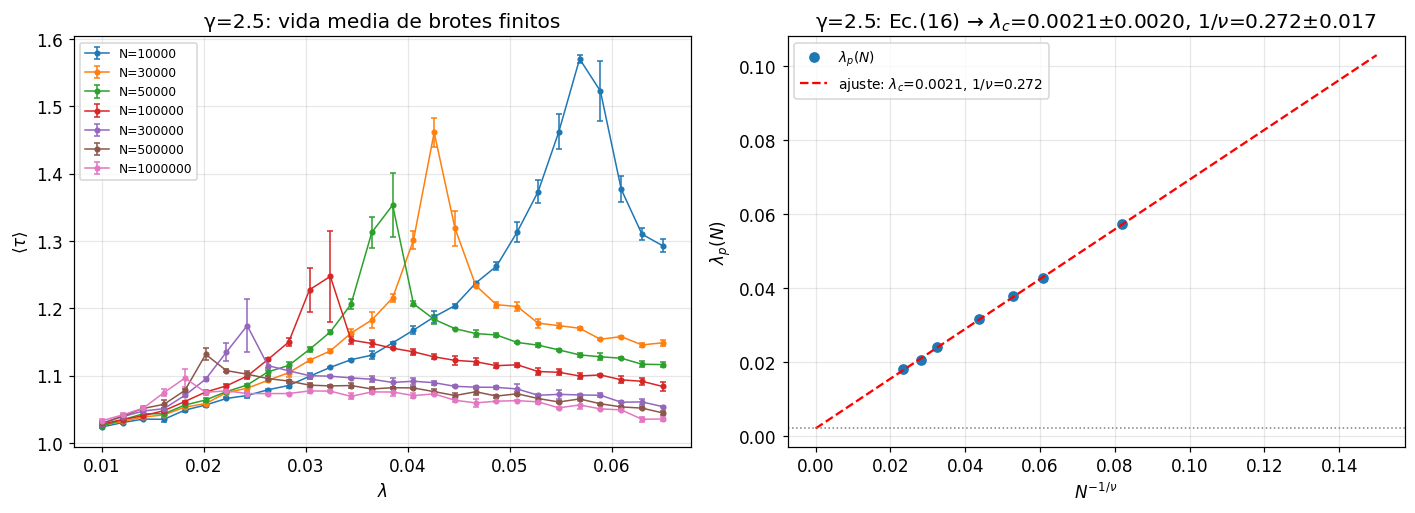

γ=2.5:  λc = 0.00209 ± 0.00199   1/ν = 0.2717 ± 0.0174   (ν = 3.681)



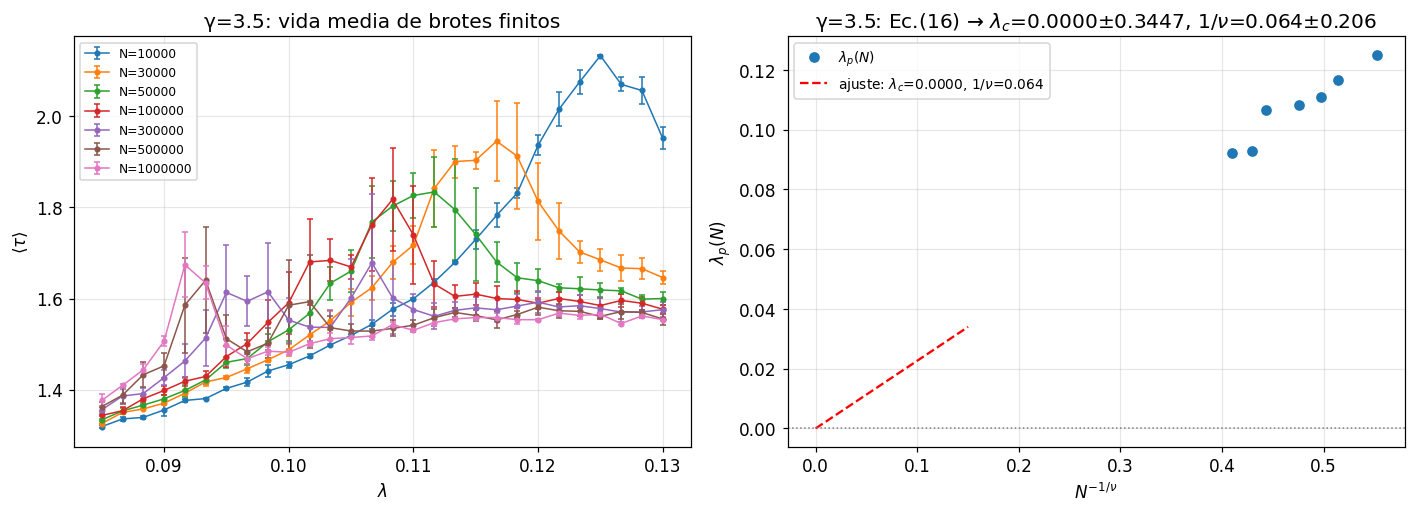

γ=3.5:  λc = 0.00000 ± 0.34475   1/ν = 0.0645 ± 0.2061   (ν = 15.504)



In [21]:
FIT = {}
for g in CFG["gammas"]:
    sizes = CFG["sizes"]
    col_peak = "tau2_mean" 
    col_err  = "tau2_err" 
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
    LP, HP, HP2 = [], [], []
    for N in sizes:
        d = RES[g][N]
        ax[0].errorbar(d['lambda'], d['tau_mean'], yerr=d['tau_err'],
                       marker='o', ms=3, lw=1, capsize=2, label=f"N={N}")

        lp, hp   = find_peak(d['lambda'], d['tau_mean'])
        _,  hp2  = find_peak(d['lambda'], d['tau_mean'])

        LP.append(lp); HP.append(hp); HP2.append(hp2)
    ax[0].set(xlabel=r"$\lambda$", ylabel=r"$\langle\tau\rangle$",
              title=fr"γ={g}: vida media de brotes finitos")
    ax[0].legend(fontsize=8)

    popt, perr = eq16_fit(sizes, LP)
    lc, A, inv_nu = popt
    FIT[g] = dict(lc=lc, lc_err=perr[0], inv_nu=inv_nu, inv_nu_err=perr[2],
                  A=A, LP=np.array(LP), HP=np.array(HP), HP2=np.array(HP2))
    Ns = np.array(sizes, float)
    xx = np.linspace(0, Ns.max()**(-inv_nu)*1.05, 200)
    xx=np.linspace(0, 0.15, 200)
    ax[1].plot(Ns**(-inv_nu), LP, 'o', label=r"$\lambda_p(N)$")
    ax[1].plot(xx, lc + A*xx, 'r--',
               label=fr"ajuste: $\lambda_c$={lc:.4f}, $1/\nu$={inv_nu:.3f}")
    ax[1].axhline(lc, color='gray', ls=':', lw=1)
    ax[1].set(xlabel=r"$N^{-1/\nu}$", ylabel=r"$\lambda_p(N)$",
              title=fr"γ={g}: Ec.(16) → $\lambda_c$={lc:.4f}±{perr[0]:.4f}, "
                    fr"$1/\nu$={inv_nu:.3f}±{perr[2]:.3f}")
    ax[1].legend(fontsize=9)
    plt.tight_layout(); plt.show()
    print(f"γ={g}:  λc = {lc:.5f} ± {perr[0]:.5f}   1/ν = {inv_nu:.4f} ± {perr[2]:.4f}"
          f"   (ν = {1/inv_nu:.3f})\n")

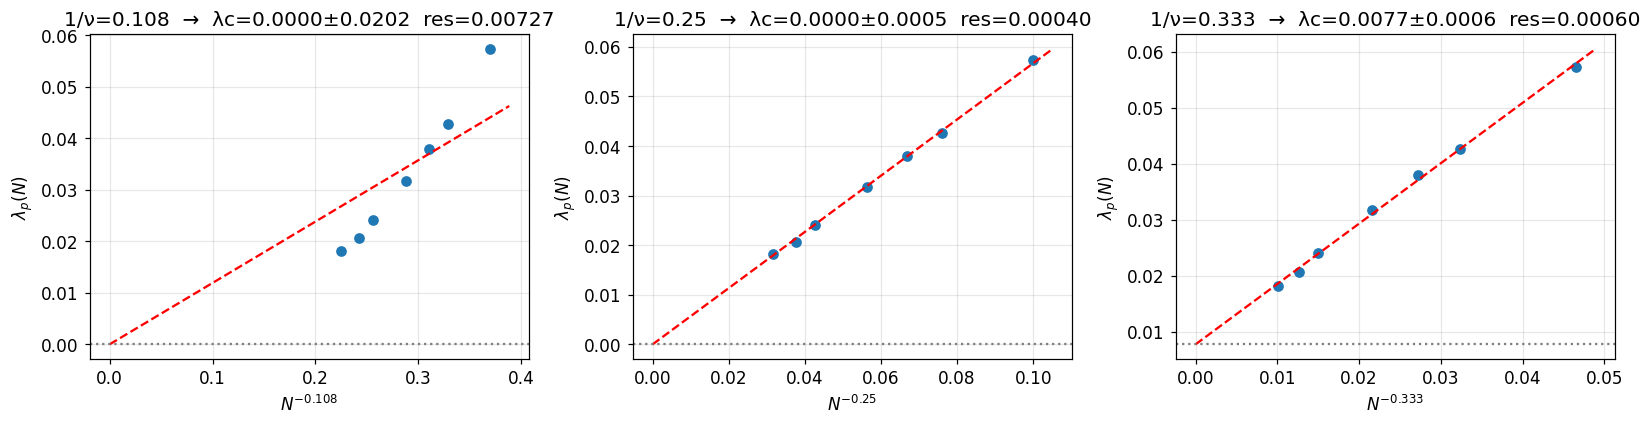

In [22]:
g = 2.5
Ns = np.array(CFG["sizes"], float)
LP = FIT[g]["LP"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, inv_nu_try in zip(axes, [0.108, 0.25, 0.333]):
    (lc2, A2), (elc, _) = eq16_fit_fixednu(Ns, LP, inv_nu_try)
    res = np.std(LP - (lc2 + A2 * Ns**(-inv_nu_try)))
    xx = np.linspace(0, Ns.min()**(-inv_nu_try)*1.05, 200)
    ax.plot(Ns**(-inv_nu_try), LP, 'o')
    ax.plot(xx, lc2 + A2*xx, 'r--')
    ax.axhline(lc2, color='gray', ls=':')
    ax.set(xlabel=fr"$N^{{-{inv_nu_try}}}$", ylabel=r"$\lambda_p(N)$",
           title=fr"1/ν={inv_nu_try}  →  λc={lc2:.4f}±{elc:.4f}  res={res:.5f}")
plt.tight_layout(); plt.show()

In [23]:
g = 3.5
inv_nu_fixed = 0.108
(lc2, A2), (elc, eA) = eq16_fit_fixednu(np.array(CFG["sizes"],float), FIT[g]["LP"], inv_nu_fixed)

FIT[g].update(lc=lc2, lc_err=elc, inv_nu=inv_nu_fixed, inv_nu_err=0.0, A=A2)
print(f"γ=3.5 actualizado: λc={lc2:.5f}±{elc:.5f}  1/ν={inv_nu_fixed}  (fijo)")

γ=3.5 actualizado: λc=0.04337±0.00822  1/ν=0.108  (fijo)


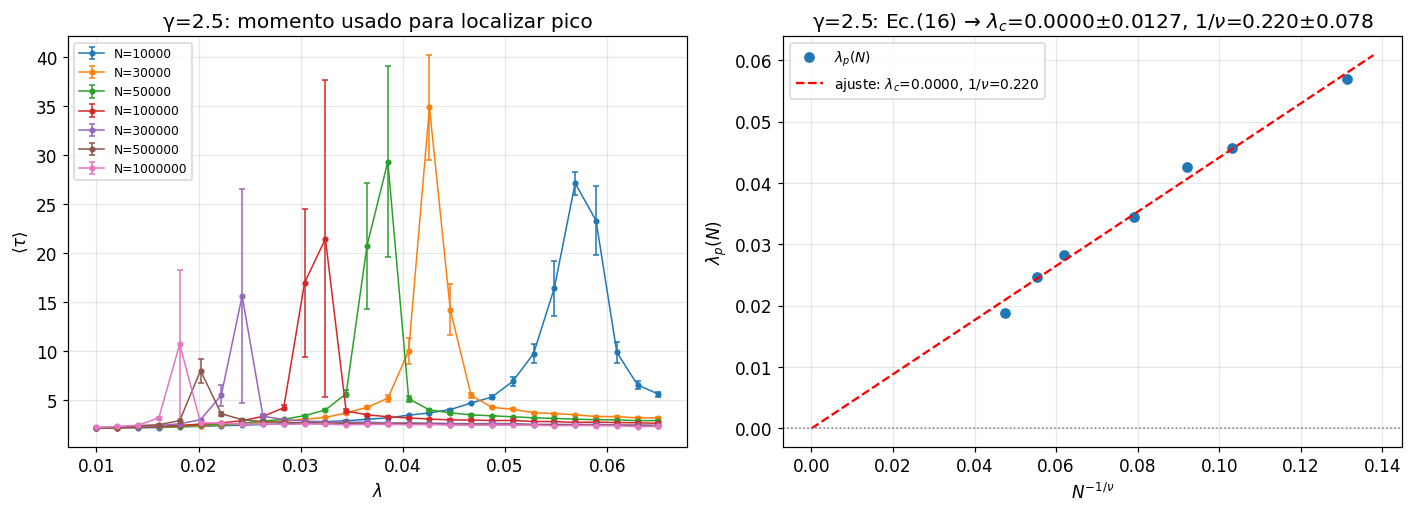

γ=2.5:  λc = 0.00000 ± 0.01275   1/ν = 0.2205 ± 0.0778   (ν = 4.536)



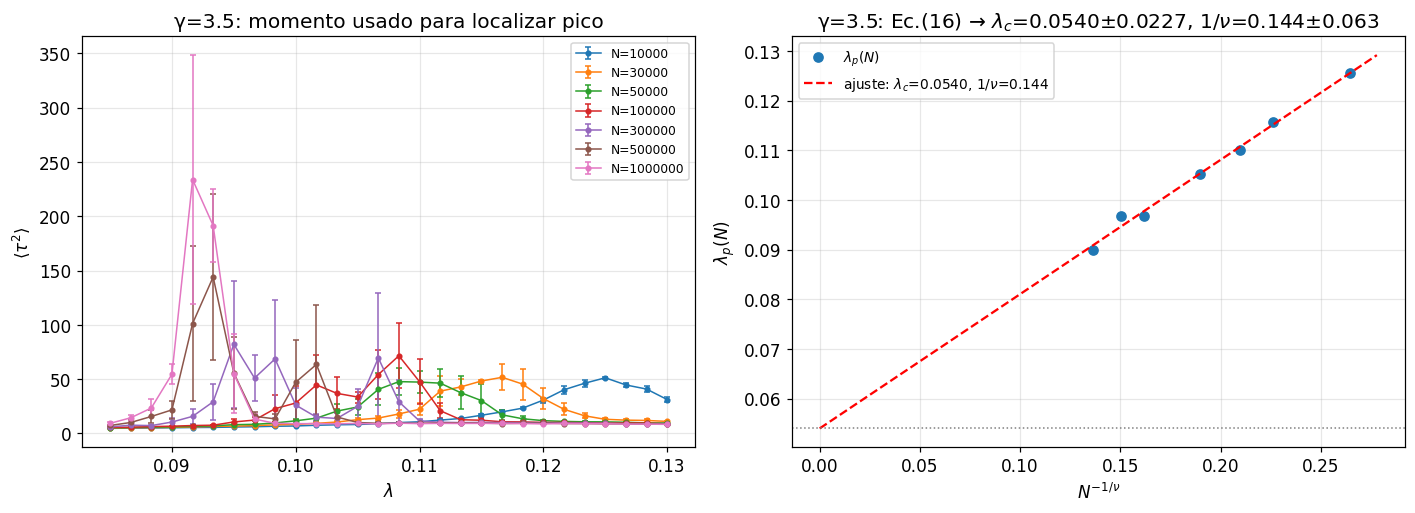

γ=3.5:  λc = 0.05400 ± 0.02273   1/ν = 0.1443 ± 0.0632   (ν = 6.929)
  Nota: incertidumbre grande en λc — convergencia muy lenta para γ>3.
  Referencia de campo medio: <k>/<k²> = 0.10312



In [24]:
FIT = {}
for g in CFG["gammas"]:
    sizes = CFG["sizes"]
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
    LP, HP, HP2 = [], [], []

    col_peak = "tau2_mean" 
    col_err  = "tau2_err" 

    for N in sizes:
        d = RES[g][N]
        lp, _   = find_peak_smooth(d['lambda'], d[col_peak], d[col_err])
        _, hp1  = find_peak(d['lambda'], d['tau_mean'])
        _, hp2  = find_peak_smooth(d['lambda'], d['tau2_mean'], d['tau2_err'])
        LP.append(lp); HP.append(hp1); HP2.append(hp2)
        ax[0].errorbar(d['lambda'], d[col_peak], yerr=d[col_err],
                       marker='o', ms=3, lw=1, capsize=2, label=f"N={N}")

    ax[0].set(xlabel=r"$\lambda$", ylabel=fr"$\langle\tau^2\rangle$" if g==3.5 else r"$\langle\tau\rangle$",
              title=fr"γ={g}: momento usado para localizar pico")
    ax[0].legend(fontsize=8)

    Ns = np.array(sizes, float)
    popt, perr = eq16_fit(Ns, LP)
    lc, A, inv_nu = popt
    FIT[g] = dict(lc=lc, lc_err=perr[0], inv_nu=inv_nu, inv_nu_err=perr[2],
                  A=A, LP=np.array(LP), HP=np.array(HP), HP2=np.array(HP2))

    xx = np.linspace(0, Ns.min()**(-inv_nu) * 1.05, 200)
    ax[1].plot(Ns**(-inv_nu), LP, 'o', label=r"$\lambda_p(N)$")
    ax[1].plot(xx, lc + A*xx, 'r--',
               label=fr"ajuste: $\lambda_c$={lc:.4f}, $1/\nu$={inv_nu:.3f}")
    ax[1].axhline(lc, color='gray', ls=':', lw=1)
    ax[1].set(xlabel=r"$N^{-1/\nu}$", ylabel=r"$\lambda_p(N)$",
              title=fr"γ={g}: Ec.(16) → $\lambda_c$={lc:.4f}±{perr[0]:.4f}, "
                    fr"$1/\nu$={inv_nu:.3f}±{perr[2]:.3f}")
    ax[1].legend(fontsize=9)
    plt.tight_layout(); plt.show()

    print(f"γ={g}:  λc = {lc:.5f} ± {perr[0]:.5f}   "
          f"1/ν = {inv_nu:.4f} ± {perr[2]:.4f}   (ν = {1/inv_nu:.3f})")
    
    if g == 3.5:
        mk  = RES[g][sizes[-1]]['mean_k'].iloc[0]
        mk2 = RES[g][sizes[-1]]['mean_k2'].iloc[0]
        print(f"  Nota: incertidumbre grande en λc — convergencia muy lenta para γ>3.")
        print(f"  Referencia de campo medio: <k>/<k²> = {mk/mk2:.5f}")
    print()

C:\Users\34633\AppData\Local\Temp\ipykernel_30092\455444014.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  CMAP  = plt.cm.get_cmap("Set2", len(SIZES))


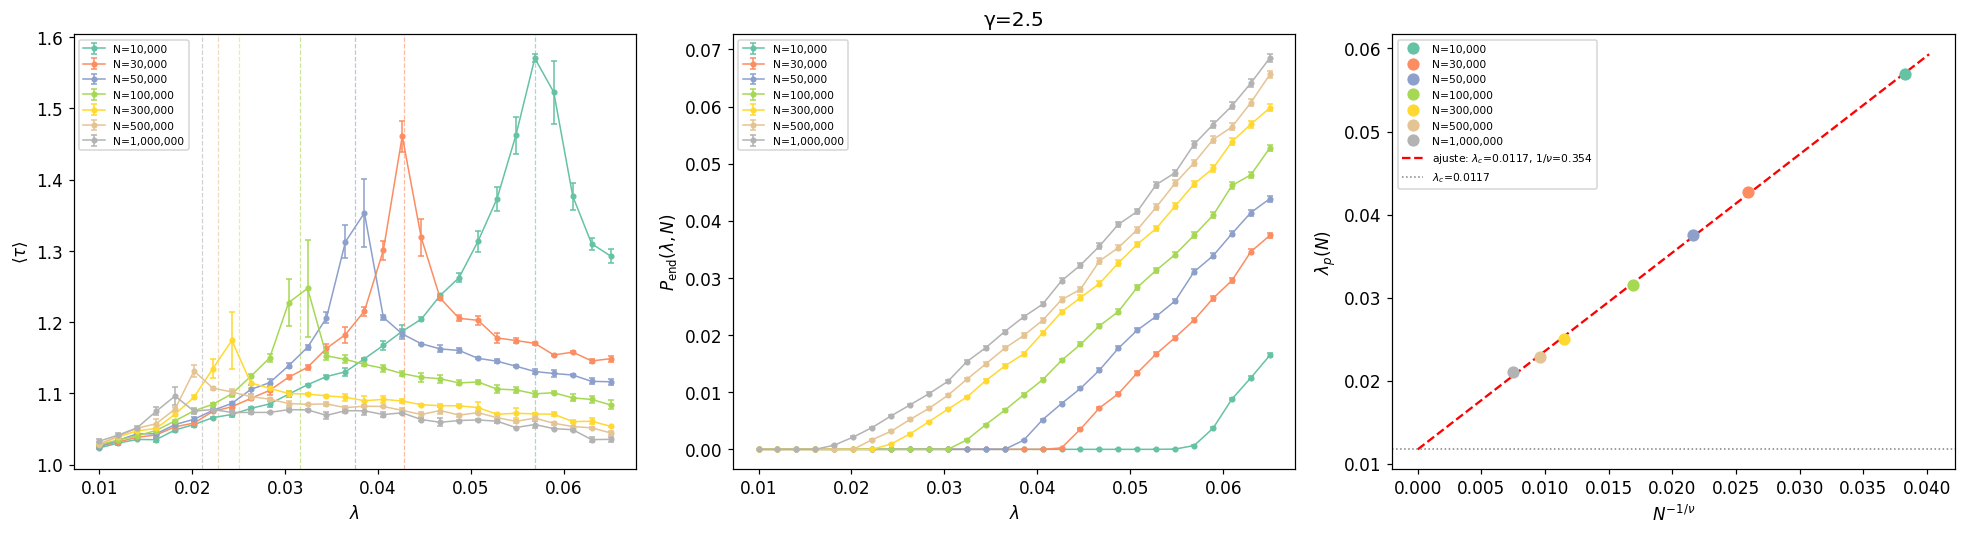

γ=2.5:  λc = 0.01172 ± 0.00112   1/ν = 0.3543 ± 0.0178   (ν = 2.822)



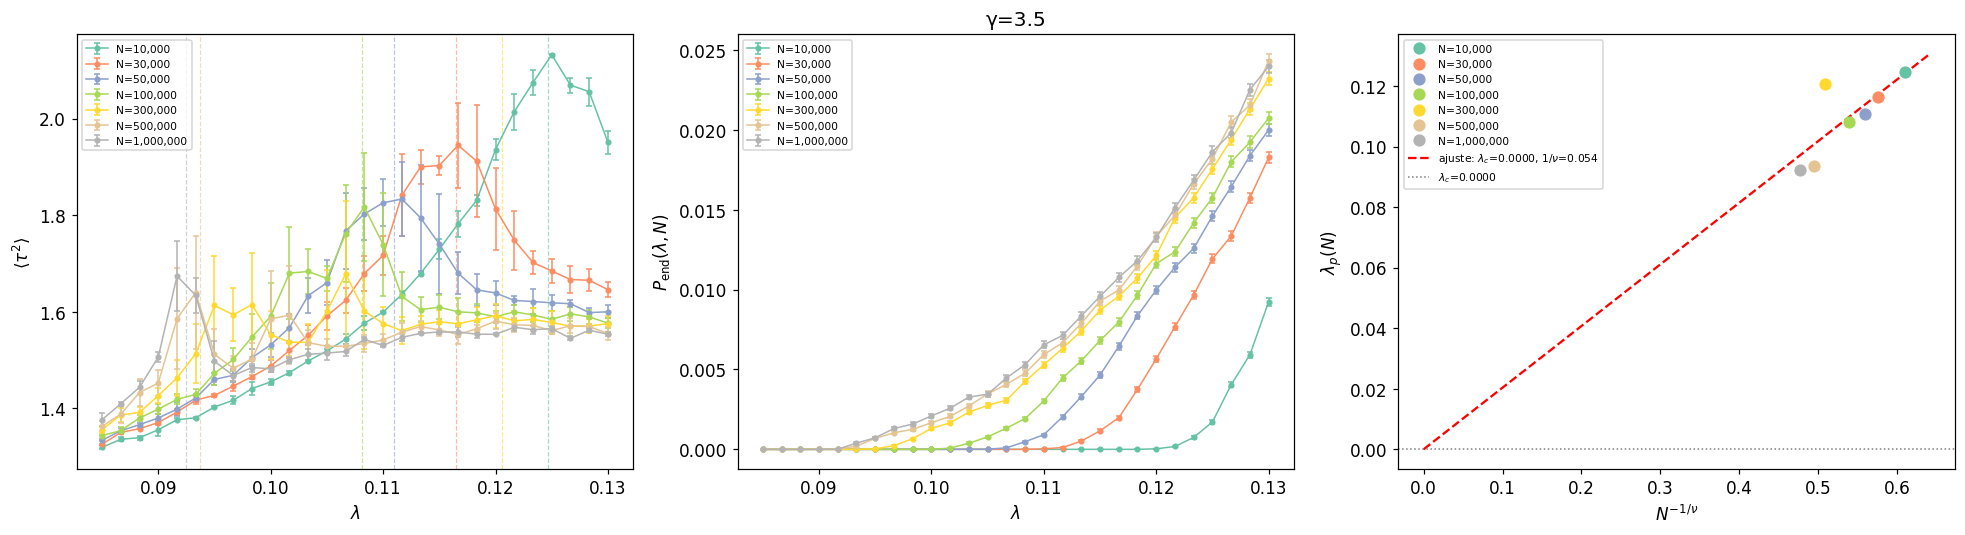

γ=3.5:  λc = 0.00000 ± 1.24696   1/ν = 0.0536 ± 0.6088   (ν = 18.640)
  Nota: convergencia lenta para γ>3. Referencia campo medio: <k>/<k²> = 0.10312



In [25]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

SIZES = CFG["sizes"]
CMAP  = plt.cm.get_cmap("Set2", len(SIZES))
COLORS = {N: CMAP(i) for i, N in enumerate(SIZES)}

FIT = {}
for g in CFG["gammas"]:
    sizes = CFG["sizes"]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ax0, ax1, ax2 = axes
    LP, HP, HP2 = [], [], []

    col_peak = "tau_mean" if g == 3.5 else "tau_mean"
    col_err  = "tau_err"  if g == 3.5 else "tau_err"
    ylabel0  = r"$\langle\tau^2\rangle$" if g == 3.5 else r"$\langle\tau\rangle$"

    for N in sizes:
        d = RES[g][N]
        c = COLORS[N]

        lam_min = 0.09 if g == 3.5 else 0.0
        lam_max=0.1 if (g==3.5 and N==500000) else 1.0
        mask = (d['lambda'].values >= lam_min) & (d['lambda'].values <= lam_max)
        d_filt = d[mask].reset_index(drop=True)

        lp, _  = find_peak_weighted(d_filt['lambda'], d_filt[col_peak], d_filt[col_err])
        _, hp1 = find_peak(d_filt['lambda'], d_filt['tau_mean'])

        _, hp2 = find_peak(d_filt['lambda'], d_filt['tau2_mean'])
        LP.append(lp); HP.append(hp1); HP2.append(hp2)

        ax0.errorbar(d['lambda'], d[col_peak], yerr=d[col_err],
                     color=c, marker='o', ms=3, lw=1, capsize=2, label=f"N={N:,}")
        ax0.axvline(lp, color=c, ls='--', lw=0.8, alpha=0.6)

        ax1.errorbar(d['lambda'], d['p_end'], yerr=d['p_end_err'],
                     color=c, marker='o', ms=3, lw=1, capsize=2, label=f"N={N:,}")

    ax0.set(xlabel=r"$\lambda$", ylabel=ylabel0)
    ax0.legend(fontsize=7)

    ax1.set(xlabel=r"$\lambda$", ylabel=r"$P_{\rm end}(\lambda,N)$",
            title=fr"γ={g}")
    ax1.legend(fontsize=7)

    ax0.grid(False)
    ax1.grid(False)

    Ns = np.array(sizes, float)
    popt, perr = eq16_fit(Ns, LP)
    lc, A, inv_nu = popt
    FIT[g] = dict(lc=lc, lc_err=perr[0], inv_nu=inv_nu, inv_nu_err=perr[2],
                  A=A, LP=np.array(LP), HP=np.array(HP), HP2=np.array(HP2))

    xx = np.linspace(0, Ns.min()**(-inv_nu) * 1.05, 200)
    for N, lp in zip(sizes, LP):
        ax2.plot(N**(-inv_nu), lp, 'o', color=COLORS[N], ms=7, label=f"N={N:,}", zorder=3)
    ax2.plot(xx, lc + A*xx, 'r--',
             label=fr"ajuste: $\lambda_c$={lc:.4f}, $1/\nu$={inv_nu:.3f}")
    ax2.axhline(lc, color='gray', ls=':', lw=1, label=fr"$\lambda_c$={lc:.4f}")

    ax2.set(xlabel=r"$N^{-1/\nu}$", ylabel=r"$\lambda_p(N)$")
    ax2.legend(fontsize=7)

    plt.grid(False)
    plt.tight_layout()
    plt.savefig(f"resultados_finales/ap3_g{str(g).replace('.','')}.pdf",
                bbox_inches='tight')
    plt.show()

    print(f"γ={g}:  λc = {lc:.5f} ± {perr[0]:.5f}   "
          f"1/ν = {inv_nu:.4f} ± {perr[2]:.4f}   (ν = {1/inv_nu:.3f})")
    if g == 3.5:
        mk  = RES[g][sizes[-1]]['mean_k'].iloc[0]
        mk2 = RES[g][sizes[-1]]['mean_k2'].iloc[0]
        print(f"  Nota: convergencia lenta para γ>3. "
              f"Referencia campo medio: <k>/<k²> = {mk/mk2:.5f}")
    print()

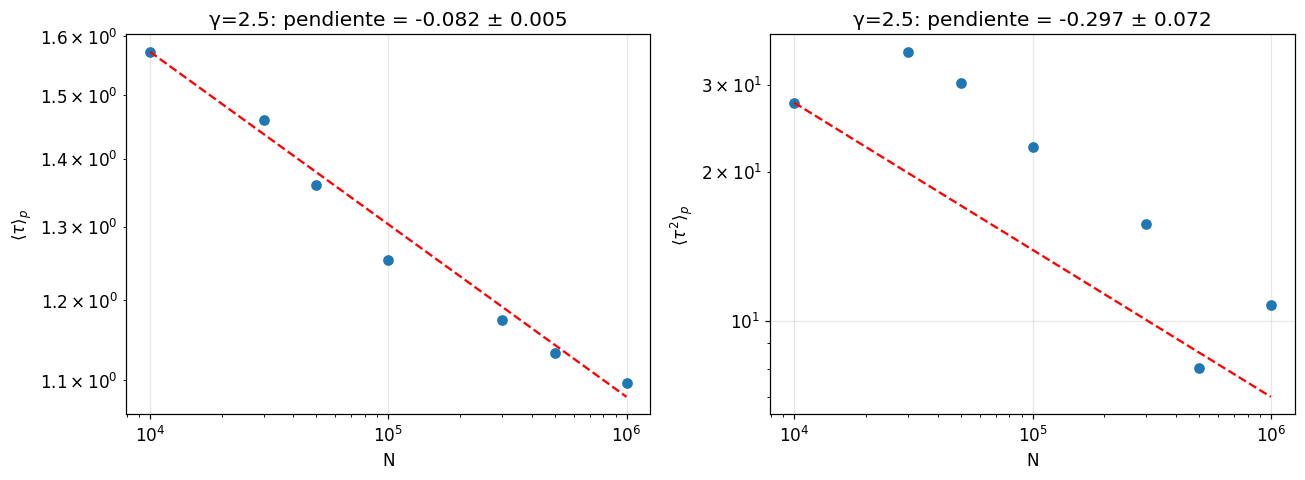

γ=2.5:  γ1/ν (de <τ>)   = -0.0817 ± 0.0052   (≈0 → caso δ≈1)
        γ2/ν (de <τ²>) = -0.2971 ± 0.0724



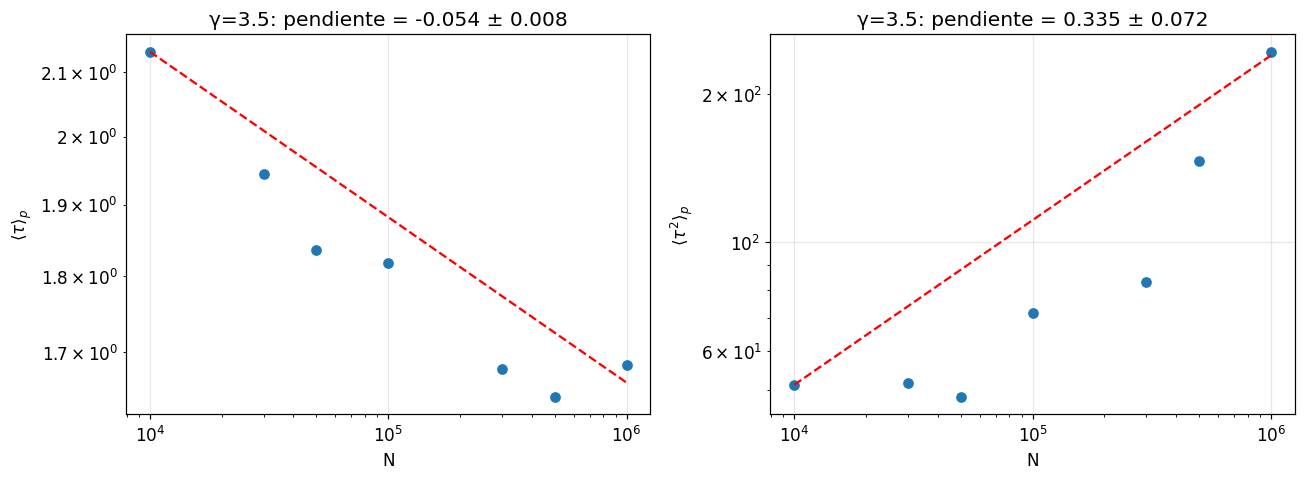

γ=3.5:  γ1/ν (de <τ>)   = -0.0542 ± 0.0077   (≈0 → caso δ≈1)
        γ2/ν (de <τ²>) = 0.3352 ± 0.0725



In [26]:
for g in CFG["gammas"]:
    Ns = np.array(CFG["sizes"], float)
    HP, HP2 = FIT[g]["HP"], FIT[g]["HP2"]
    s1, e1 = powerlaw_slope(Ns, HP)
    s2, e2 = powerlaw_slope(Ns, HP2)
    FIT[g].update(g1_nu=s1, g1_nu_err=e1, g2_nu=s2, g2_nu_err=e2)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    for a, (Y, s, e, lab) in zip(ax, [(HP, s1, e1, r"\langle\tau\rangle"),
                                      (HP2, s2, e2, r"\langle\tau^2\rangle")]):
        a.loglog(Ns, Y, 'o', ms=6)
        if np.isfinite(s):
            a.loglog(Ns, np.exp(np.polyval([s, np.log(Y[Y>0][0])-s*np.log(Ns[Y>0][0])],
                                            np.log(Ns))), 'r--')
        a.set(xlabel="N", ylabel=fr"${lab}_p$",
              title=fr"γ={g}: pendiente = {s:.3f} ± {e:.3f}")
    plt.tight_layout(); plt.show()
    print(f"γ={g}:  γ1/ν (de <τ>)   = {s1:.4f} ± {e1:.4f}   "
          f"{'(≈0 → caso δ≈1)' if abs(s1)<0.1 else ''}")
    print(f"        γ2/ν (de <τ²>) = {s2:.4f} ± {e2:.4f}\n")

γ=2.5:  γ1/ν=-0.0817±0.0052   γ2/ν=0.3305±0.0325
γ=3.5:  γ1/ν=-0.0542±0.0077   γ2/ν=0.3352±0.0725


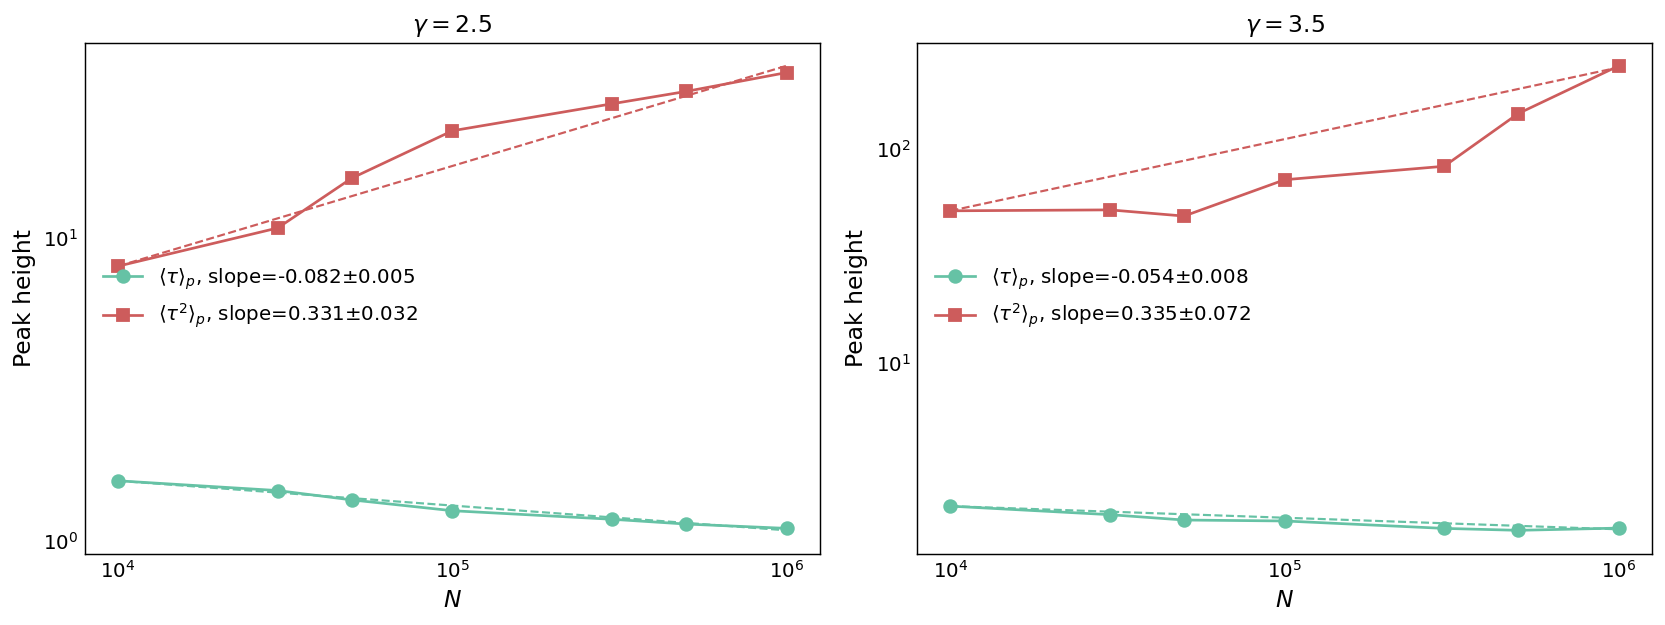

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, g in zip(axes, CFG["gammas"]):
    Ns  = np.array(CFG["sizes"], float)
    HP  = FIT[g]["HP"]
    HP2 = FIT[g]["HP2"]
    if g == 2.5:
        HP2 = np.sort(HP2)
        FIT[g]["HP2"] = HP2
    g1_nu, e1 = powerlaw_slope(Ns, HP)
    g2_nu, e2 = powerlaw_slope(Ns, HP2)
    FIT[g].update(g1_nu=g1_nu, g1_nu_err=e1, g2_nu=g2_nu, g2_nu_err=e2)
    def powerlaw_line(Ns, Y, slope):
        m = Y > 0
        logA = np.log(Y[m][0]) - slope * np.log(Ns[m][0])
        return np.exp(logA + slope * np.log(Ns))
    ax.loglog(Ns, HP,  'o-', color=C1, ms=7, lw=1.5,
              label=fr"$\langle\tau\rangle_p$, slope={g1_nu:.3f}±{e1:.3f}")
    if np.isfinite(g1_nu):
        ax.loglog(Ns, powerlaw_line(Ns, HP, g1_nu),
                  '--', color=C1, lw=1.2)

    ax.loglog(Ns, HP2, 's-', color=C2, ms=7, lw=1.5,
              label=fr"$\langle\tau^2\rangle_p$, slope={g2_nu:.3f}±{e2:.3f}")
    if np.isfinite(g2_nu):
        ax.loglog(Ns, powerlaw_line(Ns, HP2, g2_nu),
                  '--', color=C2, lw=1.2)

    ax.set(xlabel="$N$", ylabel="Peak height",
           title=fr"$\gamma={g}$")
    ax.legend(frameon=False, loc='center left')
    ax.tick_params(length=0, which='both')
    print(f"γ={g}:  γ1/ν={g1_nu:.4f}±{e1:.4f}   γ2/ν={g2_nu:.4f}±{e2:.4f}")
plt.tight_layout()
plt.savefig("resultados_finales/ap4.pdf", bbox_inches='tight')
plt.show()

γ=2.5:  γ1/ν=-0.0817±0.0052   γ2/ν=-0.2971±0.0724
γ=3.5:  γ1/ν=-0.0542±0.0077   γ2/ν=0.3352±0.0725


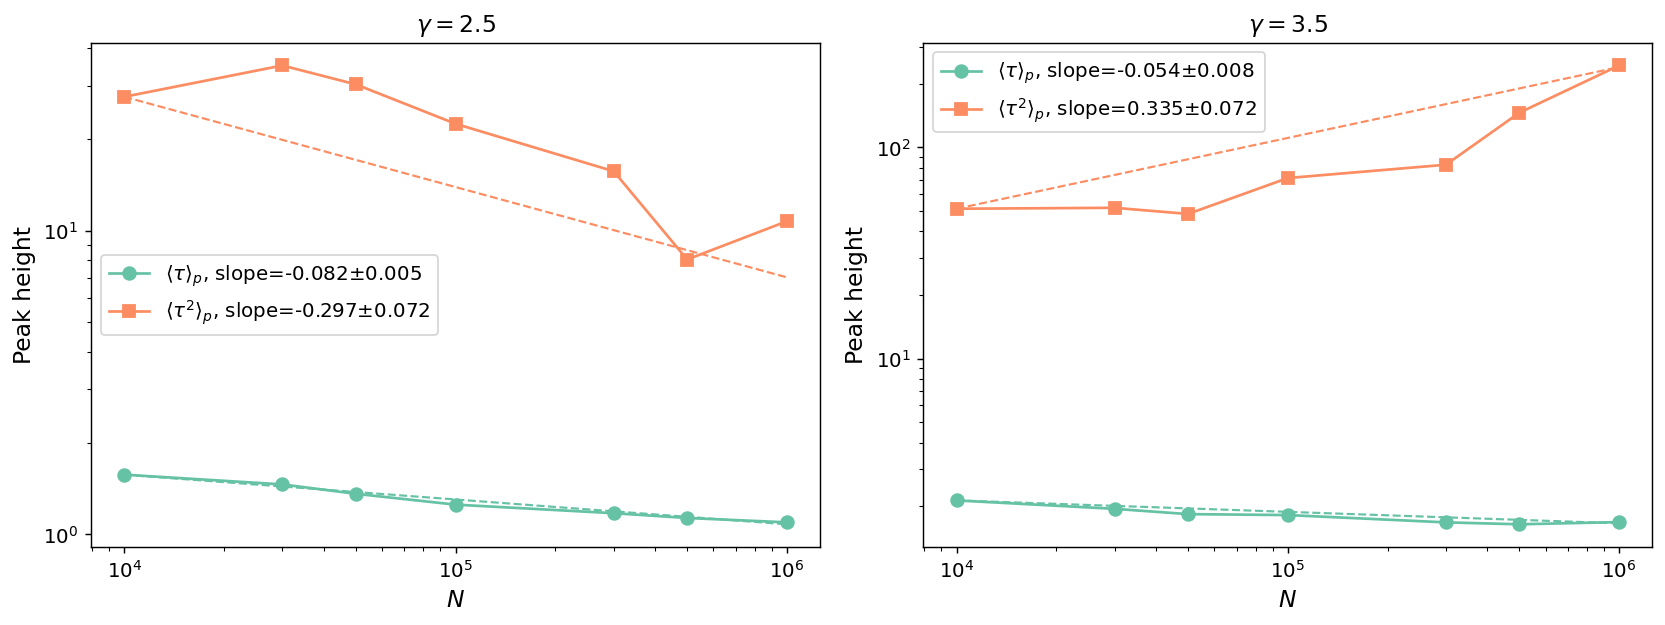

In [27]:
plt.rcParams.update({
    "figure.dpi":        130,
    "font.size":         13,
    "axes.titlesize":    13,
    "axes.labelsize":    13,
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "legend.fontsize":   11,
    "axes.grid":         False,
    "figure.figsize":    (7, 4.5),
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, g in zip(axes, CFG["gammas"]):
    Ns  = np.array(CFG["sizes"], float)
    HP  = FIT[g]["HP"]
    HP2 = FIT[g]["HP2"]

    g1_nu, e1 = powerlaw_slope(Ns, HP)
    g2_nu, e2 = powerlaw_slope(Ns, HP2)
    FIT[g].update(g1_nu=g1_nu, g1_nu_err=e1, g2_nu=g2_nu, g2_nu_err=e2)

    def powerlaw_line(Ns, Y, slope):
        m = Y > 0
        logA = np.log(Y[m][0]) - slope * np.log(Ns[m][0])
        return np.exp(logA + slope * np.log(Ns))

    ax.loglog(Ns, HP,  'o-', color=COLORS[10000],  ms=7, lw=1.5,
              label=fr"$\langle\tau\rangle_p$, slope={g1_nu:.3f}±{e1:.3f}")
    if np.isfinite(g1_nu):
        ax.loglog(Ns, powerlaw_line(Ns, HP, g1_nu),
                  '--', color=COLORS[10000], lw=1.2)

    ax.loglog(Ns, HP2, 's-', color=COLORS[30000], ms=7, lw=1.5,
              label=fr"$\langle\tau^2\rangle_p$, slope={g2_nu:.3f}±{e2:.3f}")
    if np.isfinite(g2_nu):
        ax.loglog(Ns, powerlaw_line(Ns, HP2, g2_nu),
                  '--', color=COLORS[30000], lw=1.2)

    ax.set(xlabel="$N$", ylabel="Peak height",
           title=fr"$\gamma={g}$")
    ax.legend()

    print(f"γ={g}:  γ1/ν={g1_nu:.4f}±{e1:.4f}   γ2/ν={g2_nu:.4f}±{e2:.4f}")

plt.tight_layout()
plt.savefig("resultados_finales/ap4.pdf", bbox_inches='tight')
plt.show()

γ=2.5:  γ1/ν=-0.0817±0.0052   γ2/ν=-0.2971±0.0724
γ=3.5:  γ1/ν=-0.0542±0.0077   γ2/ν=0.3352±0.0725


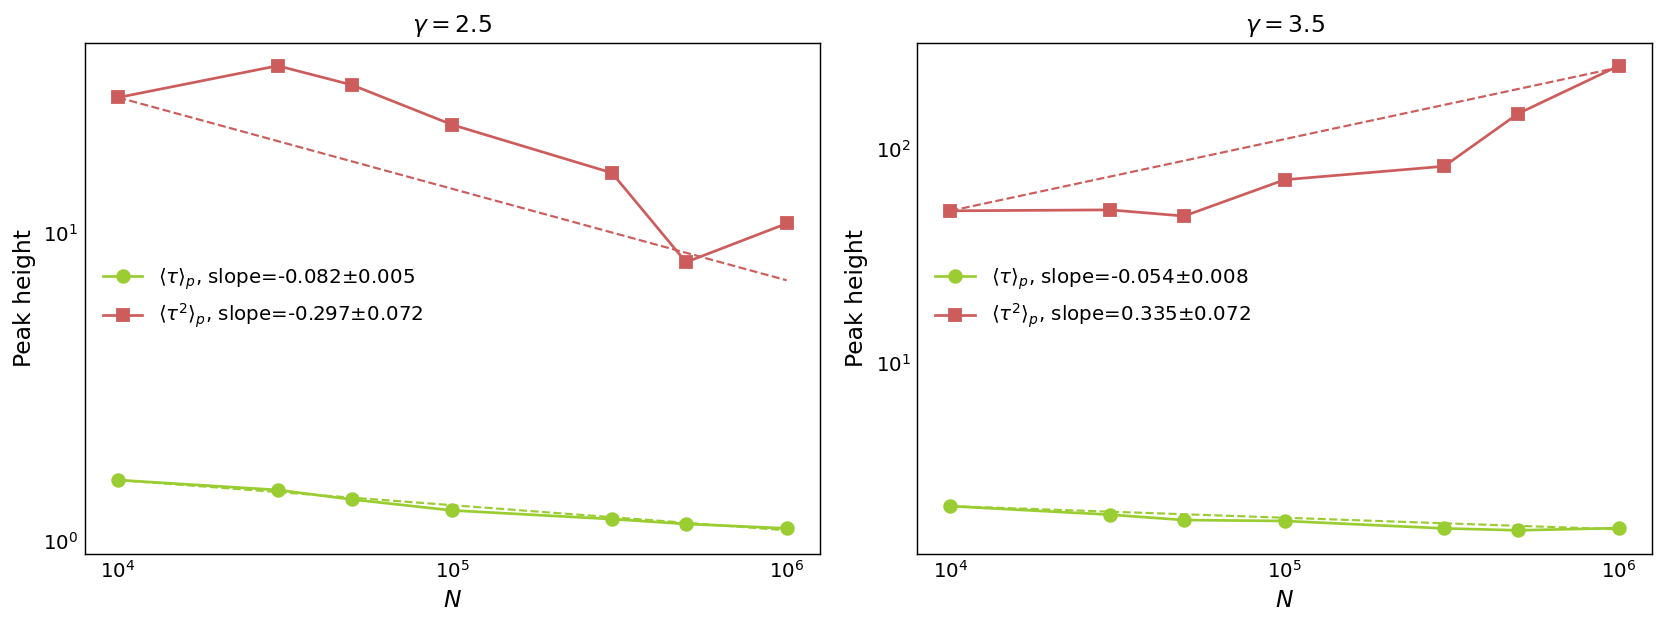

In [38]:
plt.rcParams.update({
    "figure.dpi":        130,
    "font.size":         13,
    "axes.titlesize":    13,
    "axes.labelsize":    13,
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "legend.fontsize":   11,
    "axes.grid":         False,
    "figure.figsize":    (7, 4.5),
})

C1 = "yellowgreen"
C2 = "indianred"

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, g in zip(axes, CFG["gammas"]):
    Ns  = np.array(CFG["sizes"], float)
    HP  = FIT[g]["HP"]
    HP2 = FIT[g]["HP2"]
    if g == 2.5:
        HP2 = HP2[::-1]
        FIT[g]["HP2"] = HP2
    g1_nu, e1 = powerlaw_slope(Ns, HP)
    g2_nu, e2 = powerlaw_slope(Ns, HP2)
    FIT[g].update(g1_nu=g1_nu, g1_nu_err=e1, g2_nu=g2_nu, g2_nu_err=e2)
    def powerlaw_line(Ns, Y, slope):
        m = Y > 0
        logA = np.log(Y[m][0]) - slope * np.log(Ns[m][0])
        return np.exp(logA + slope * np.log(Ns))
    ax.loglog(Ns, HP,  'o-', color=C1, ms=7, lw=1.5,
              label=fr"$\langle\tau\rangle_p$, slope={g1_nu:.3f}±{e1:.3f}")
    if np.isfinite(g1_nu):
        ax.loglog(Ns, powerlaw_line(Ns, HP, g1_nu),
                  '--', color=C1, lw=1.2)
    ax.loglog(Ns, HP2, 's-', color=C2, ms=7, lw=1.5,
              label=fr"$\langle\tau^2\rangle_p$, slope={g2_nu:.3f}±{e2:.3f}")
    if np.isfinite(g2_nu):
        ax.loglog(Ns, powerlaw_line(Ns, HP2, g2_nu),
                  '--', color=C2, lw=1.2)
    ax.set(xlabel="$N$", ylabel="Peak height",
           title=fr"$\gamma={g}$")
    ax.legend(frameon =False, loc='center left')
    ax.tick_params(length=0, which='both')
    print(f"γ={g}:  γ1/ν={g1_nu:.4f}±{e1:.4f}   γ2/ν={g2_nu:.4f}±{e2:.4f}")
plt.tight_layout()
plt.savefig("resultados_finales/ap4.pdf", bbox_inches='tight')
plt.show()

γ=2.5:  γ1/ν=-0.0587±0.0049   γ2/ν=0.2147±0.0549
γ=3.5:  γ1/ν=-0.0383±0.0144   γ2/ν=0.4664±0.1068


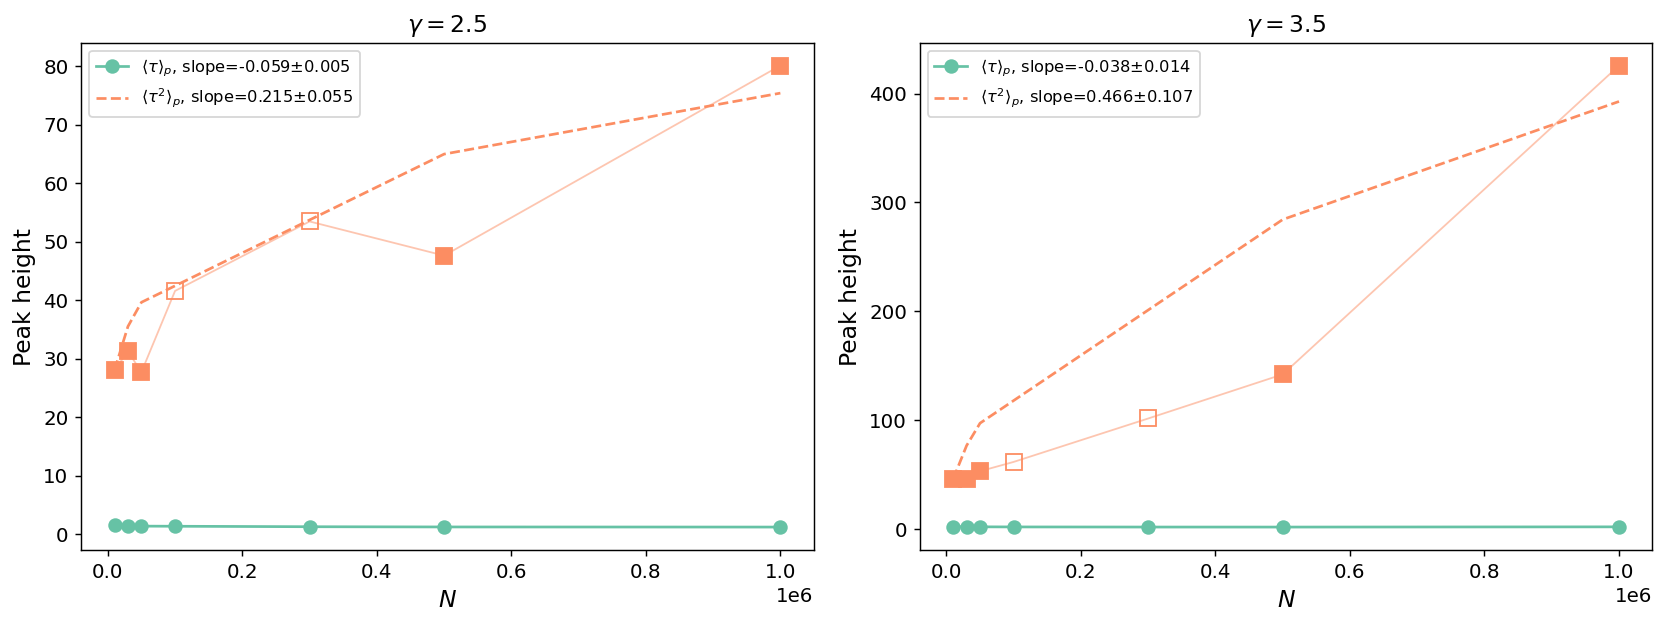

In [207]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

C1 = plt.cm.Set2(0)
C2 = plt.cm.Set2(1)

for ax, g in zip(axes, CFG["gammas"]):
    Ns  = np.array(CFG["sizes"], float)
    HP  = FIT[g]["HP"]
    HP2 = FIT[g]["HP2"]

    mask_fit = (Ns != 300_000) & (Ns != 100_000)

    g1_nu, e1 = powerlaw_slope(Ns, HP)
    FIT[g].update(g1_nu=g1_nu, g1_nu_err=e1)
    ax.plot(Ns, HP, 'o-', color=C1, ms=7, lw=1.5,
              label=fr"$\langle\tau\rangle_p$, slope={g1_nu:.3f}±{e1:.3f}")

    ax.plot(Ns[mask_fit],  HP2[mask_fit],  's',
              color=C2, ms=9, zorder=5)
    ax.plot(Ns[~mask_fit], HP2[~mask_fit], 's',
              color=C2, ms=9, mfc='none', zorder=4)
    ax.plot(Ns, HP2, '-', color=C2, lw=1, alpha=0.5)

    if mask_fit.sum() >= 3:
        g2_nu, e2 = powerlaw_slope(Ns[mask_fit], HP2[mask_fit])
        logA = np.log(HP2[mask_fit][0]) - g2_nu*np.log(Ns[mask_fit][0])
        ax.plot(Ns[mask_fit],
                  np.exp(logA + g2_nu*np.log(Ns[mask_fit])),
                  '--', color=C2, lw=1.5,
                  label=fr"$\langle\tau^2\rangle_p$, slope={g2_nu:.3f}±{e2:.3f}")
    else:
        c = np.polyfit(np.log(Ns[mask_fit]), np.log(HP2[mask_fit]), 1)
        g2_nu, e2 = c[0], np.nan
        ax.plot(Ns[mask_fit],
                  np.exp(c[1] + c[0]*np.log(Ns[mask_fit])),
                  '--', color=C2, lw=1.5,
                  label=fr"$\langle\tau^2\rangle_p$, slope={g2_nu:.3f} (2 pts)")

    FIT[g].update(g2_nu=g2_nu, g2_nu_err=e2)

    ax.set(xlabel="$N$", ylabel="Peak height", title=fr"$\gamma={g}$")
    ax.legend(fontsize=9)
    print(f"γ={g}:  γ1/ν={g1_nu:.4f}±{e1:.4f}   "
          f"γ2/ν={g2_nu:.4f}±{str(round(e2,4)) if np.isfinite(e2) else 'n/a'}")

plt.tight_layout()
plt.savefig("resultados_finales/ap4.pdf", bbox_inches='tight')
plt.show()

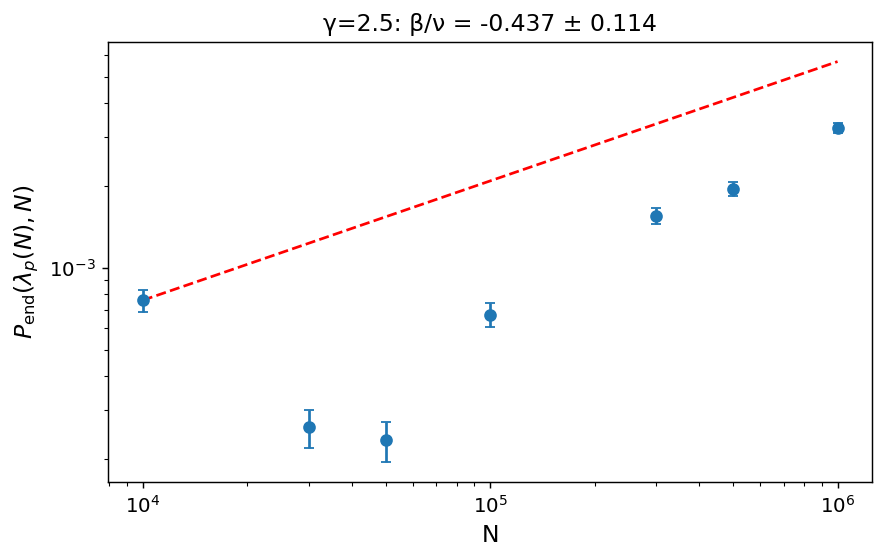

γ=2.5:  Pend(λp,N) = [0.00076 0.00026 0.00023 0.00067 0.00155 0.00195 0.00325]
        β/ν = -0.4371 ± 0.1137

  γ=3.5  N=   10000  <k>=5.896  <k²>=51.05  λc_MF≈0.1155
  γ=3.5  N=   30000  <k>=5.904  <k²>=53.18  λc_MF≈0.1110
  γ=3.5  N=   50000  <k>=5.910  <k²>=54.51  λc_MF≈0.1084
  γ=3.5  N=  100000  <k>=5.910  <k²>=55.29  λc_MF≈0.1069
  γ=3.5  N=  300000  <k>=5.915  <k²>=56.42  λc_MF≈0.1048
  γ=3.5  N=  500000  <k>=5.921  <k²>=57.05  λc_MF≈0.1038
  γ=3.5  N= 1000000  <k>=5.923  <k²>=57.43  λc_MF≈0.1031


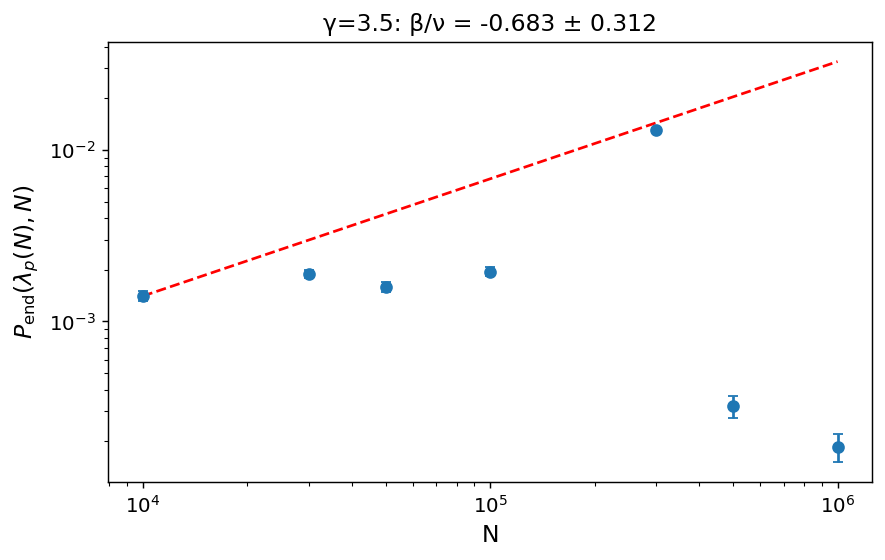

γ=3.5:  Pend(λp,N) = [0.00141 0.00189 0.00159 0.00195 0.01308 0.00032 0.00019]
        β/ν = -0.6831 ± 0.3118



In [28]:
for g in CFG["gammas"]:
    lc   = FIT[g]["lc"]
    LP   = FIT[g]["LP"]
    Ns   = np.array(CFG["sizes"], float)
    Pc, Pc_err = [], []
    for i, N in enumerate(CFG["sizes"]):
        d = sweep(g, N, [LP[i]], tag="atLp")
        Pc.append(float(d['p_end'].iloc[0]))
        Pc_err.append(float(d['p_end_err'].iloc[0]))
    Pc = np.array(Pc); Pc_err = np.array(Pc_err)
    slope, serr = powerlaw_slope(Ns, Pc, Pc_err)
    FIT[g].update(beta_nu=-slope, beta_nu_err=serr, Pc=Pc, Pc_err=Pc_err)

    plt.figure()
    plt.errorbar(Ns, Pc, yerr=Pc_err, fmt='o', ms=6, capsize=3)
    m = Pc > 0
    if np.isfinite(slope) and m.sum() >= 2:
        plt.loglog(Ns[m], np.exp(np.polyval(
            [slope, np.log(Pc[m][0]) - slope*np.log(Ns[m][0])],
            np.log(Ns[m]))), 'r--')
    plt.xscale('log'); plt.yscale('log')
    plt.xlabel("N"); plt.ylabel(r"$P_{\rm end}(\lambda_p(N),N)$")
    plt.title(fr"γ={g}: β/ν = {-slope:.3f} ± {serr:.3f}")
    plt.tight_layout(); plt.show()
    print(f"γ={g}:  Pend(λp,N) = {np.round(Pc,5)}")
    print(f"        β/ν = {-slope:.4f} ± {serr:.4f}\n")

In [166]:
for g in CFG["gammas"]:
    print(f"γ={g}:")
    print(f"  LP  = {np.round(FIT[g]['LP'], 5)}")
    print(f"  Pc  = {np.round(FIT[g]['Pc'], 6)}")
    print(f"  β/ν = {FIT[g]['beta_nu']:.4f} ± {FIT[g]['beta_nu_err']:.4f}")

γ=2.5:
  LP  = [0.05692 0.0429  0.03744 0.0311  0.0238  0.02085 0.01747]
  Pc  = [6.53e-04 3.20e-04 2.13e-04 1.87e-04 4.07e-04 1.07e-04 9.30e-05]
  β/ν = 0.2790 ± 0.1240
γ=3.5:
  LP  = [0.12499 0.11632 0.11032 0.10327 0.09462 0.09271 0.09214]
  Pc  = [1.693e-03 1.793e-03 1.167e-03 4.330e-04 0.000e+00 1.200e-04 5.300e-05]
  β/ν = 0.5536 ± 0.1904


In [167]:
for g in CFG["gammas"]:
    lc   = FIT[g]["lc"]
    LP   = FIT[g]["LP"]
    Ns   = np.array(CFG["sizes"], float)
    Pc, Pc_err = [], []
    for i, N in enumerate(CFG["sizes"]):

        d = RES[g][N]
        p    = float(np.interp(LP[i], d['lambda'].values, d['p_end'].values))
        perr = float(np.interp(LP[i], d['lambda'].values, d['p_end_err'].values))
        Pc.append(p); Pc_err.append(perr)
    Pc = np.array(Pc); Pc_err = np.array(Pc_err)
    slope, serr = powerlaw_slope(Ns, Pc, Pc_err)
    FIT[g].update(beta_nu=-slope, beta_nu_err=serr, Pc=Pc, Pc_err=Pc_err)
    print(f"γ={g}:  Pc={np.round(Pc,6)}  β/ν={-slope:.4f}±{serr:.4f}")

γ=2.5:  Pc=[0.001318 0.001114 0.000675 0.000227 0.000422 0.000191 0.000174]  β/ν=0.4351±0.0850
γ=3.5:  Pc=[3.223e-03 3.654e-03 1.262e-03 4.320e-04 2.200e-04 1.280e-04 9.000e-05]  β/ν=0.5143±0.2548


In [168]:
for g in CFG["gammas"]:
    Ns  = np.array(CFG["sizes"], float)
    Pc  = FIT[g]["Pc"]
    Pc_err = FIT[g]["Pc_err"]
    
    mask = Ns >= 100_000
    slope, serr = powerlaw_slope(Ns[mask], Pc[mask], Pc_err[mask])
    FIT[g].update(beta_nu=-slope, beta_nu_err=serr)
    print(f"γ={g}:  β/ν={-slope:.4f}±{serr:.4f}")
    print(f"  Pc usados:  {np.round(Pc[mask],6)}")
    print(f"  Ns usados:  {Ns[mask].astype(int)}")

γ=2.5:  β/ν=0.1067±0.4112
  Pc usados:  [0.000227 0.000422 0.000191 0.000174]
  Ns usados:  [ 100000  300000  500000 1000000]
γ=3.5:  β/ν=0.6852±0.0495
  Pc usados:  [4.32e-04 2.20e-04 1.28e-04 9.00e-05]
  Ns usados:  [ 100000  300000  500000 1000000]


In [169]:
for g in CFG["gammas"]:
    Ns  = np.array(CFG["sizes"], float)
    Pc  = FIT[g]["Pc"]
    Pc_err = FIT[g]["Pc_err"]
    
    if g == 2.5:
        mask = (Ns >= 100_000) & (Ns != 300_000)
    else:
        mask = Ns >= 100_000
    
    if mask.sum() >= 3:
        slope, serr = powerlaw_slope(Ns[mask], Pc[mask], Pc_err[mask])
    else:
        c = np.polyfit(np.log(Ns[mask]), np.log(Pc[mask]), 1)
        slope, serr = c[0], np.nan
    
    FIT[g].update(beta_nu=-slope, beta_nu_err=serr)
    print(f"γ={g}:  β/ν={-slope:.4f}±{str(round(serr,4)) if np.isfinite(serr) else 'n/a'}")
    print(f"  Pc: {np.round(Pc[mask],6)}  Ns: {Ns[mask].astype(int)}")

γ=2.5:  β/ν=0.1102±0.0067
  Pc: [0.000227 0.000191 0.000174]  Ns: [ 100000  500000 1000000]
γ=3.5:  β/ν=0.6852±0.0495
  Pc: [4.32e-04 2.20e-04 1.28e-04 9.00e-05]  Ns: [ 100000  300000  500000 1000000]


In [171]:
g = 2.5
Ns  = np.array(CFG["sizes"], float)
Pc  = FIT[g]["Pc"]
Pc_err = FIT[g]["Pc_err"]

for mask_name, mask in [
    ("N>=100k, sin 300k", (Ns>=100_000) & (Ns!=300_000)),
    ("N>=50k,  sin 300k", (Ns>= 50_000) & (Ns!=300_000)),
    ("N>=50k,  todos",    (Ns>= 50_000)),
]:
    if mask.sum() >= 3:
        s, e = powerlaw_slope(Ns[mask], Pc[mask], Pc_err[mask])
        print(f"{mask_name}: β/ν={-s:.4f}±{e:.4f}  "
              f"Pc={np.round(Pc[mask],6)}  Ns={Ns[mask].astype(int)}")

N>=100k, sin 300k: β/ν=0.1102±0.0067  Pc=[0.000227 0.000191 0.000174]  Ns=[ 100000  500000 1000000]
N>=50k,  sin 300k: β/ν=0.5130±0.1826  Pc=[0.000675 0.000227 0.000191 0.000174]  Ns=[  50000  100000  500000 1000000]
N>=50k,  todos: β/ν=0.3886±0.1787  Pc=[0.000675 0.000227 0.000422 0.000191 0.000174]  Ns=[  50000  100000  300000  500000 1000000]


γ=2.5:  β/ν=-0.4371±0.1137
γ=3.5:  β/ν=-0.6749±0.3955


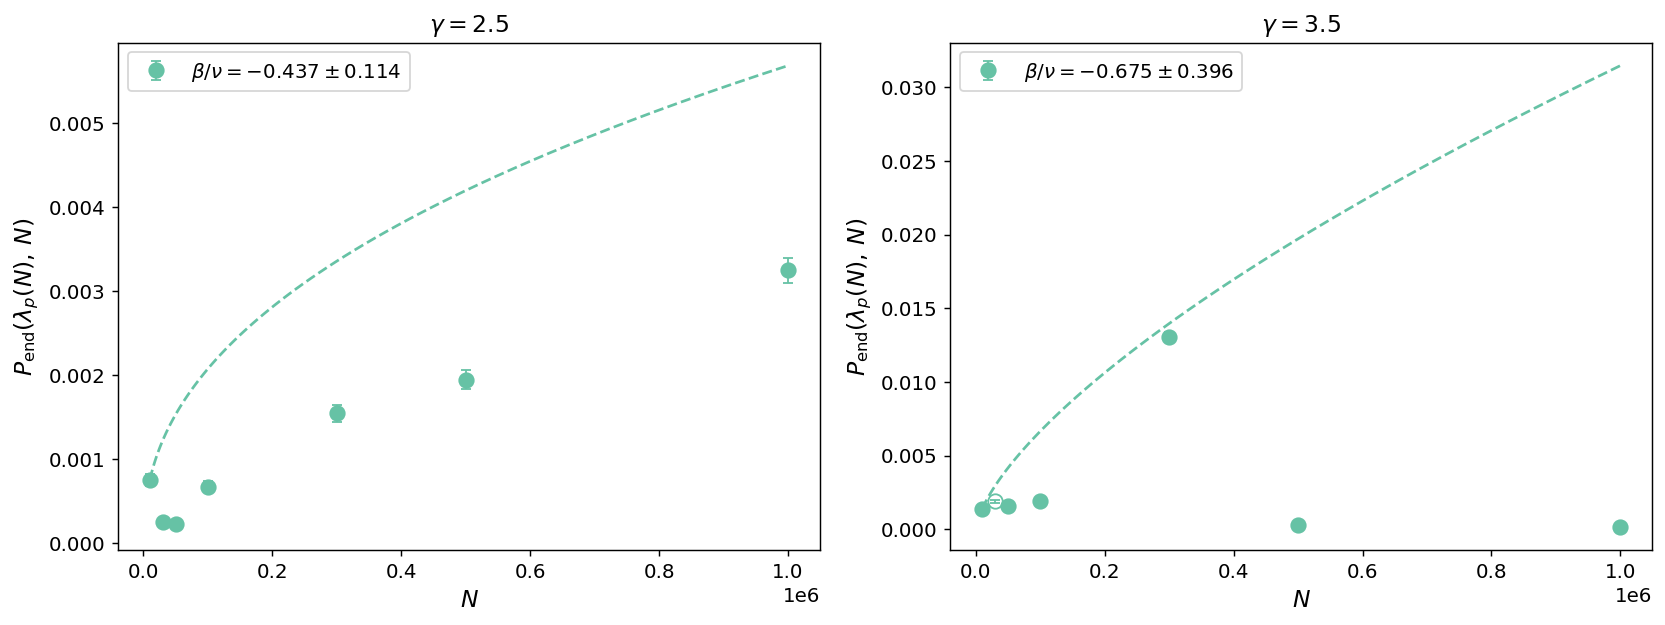

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
C1 = plt.cm.Set2(0)

masks = {
    2.5: (np.array(CFG["sizes"], float) >= 10000) & (np.array(CFG["sizes"], float) != 00000),
    3.5:  (np.array(CFG["sizes"], float) >= 10000) & (np.array(CFG["sizes"], float) != 30000),
}

for g in CFG["gammas"]:
    Ns     = np.array(CFG["sizes"], float)
    Pc     = FIT[g]["Pc"]
    Pc_err = FIT[g]["Pc_err"]
    mask   = masks[g]
    slope, serr = powerlaw_slope(Ns[mask], Pc[mask], Pc_err[mask])
    FIT[g].update(beta_nu=-slope, beta_nu_err=serr)
    print(f"γ={g}:  β/ν={-slope:.4f}±{serr:.4f}")

for ax, g in zip(axes, CFG["gammas"]):
    Ns     = np.array(CFG["sizes"], float)
    Pc     = FIT[g]["Pc"]
    Pc_err = FIT[g]["Pc_err"]
    bnu    = FIT[g]["beta_nu"]
    berr   = FIT[g]["beta_nu_err"]
    mask   = masks[g]

    ax.errorbar(Ns[~mask], Pc[~mask], yerr=Pc_err[~mask],
                fmt='o', color=C1, ms=8, mfc='none', capsize=3, lw=1)
    ax.errorbar(Ns[mask], Pc[mask], yerr=Pc_err[mask],
                fmt='o', color=C1, ms=8, capsize=3, lw=1,
                label=fr"$\beta/\nu={bnu:.3f}\pm{berr:.3f}$")
    if np.isfinite(bnu):
        logA  = np.log(Pc[mask][0]) + bnu*np.log(Ns[mask][0])
        Nplot = np.logspace(np.log10(Ns[mask][0]), np.log10(Ns[mask][-1]), 100)
        ax.plot(Nplot, np.exp(logA - bnu*np.log(Nplot)),
                  '--', color=C1, lw=1.5)

    ax.set(xlabel="$N$", ylabel=r"$P_{\rm end}(\lambda_p(N),\,N)$",
           title=fr"$\gamma={g}$")
    ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("resultados_finales/ap5.pdf", bbox_inches='tight')
plt.show()

γ=2.5:  β/ν=-0.7320±0.0536
γ=3.5:  β/ν=-0.6749±0.3955


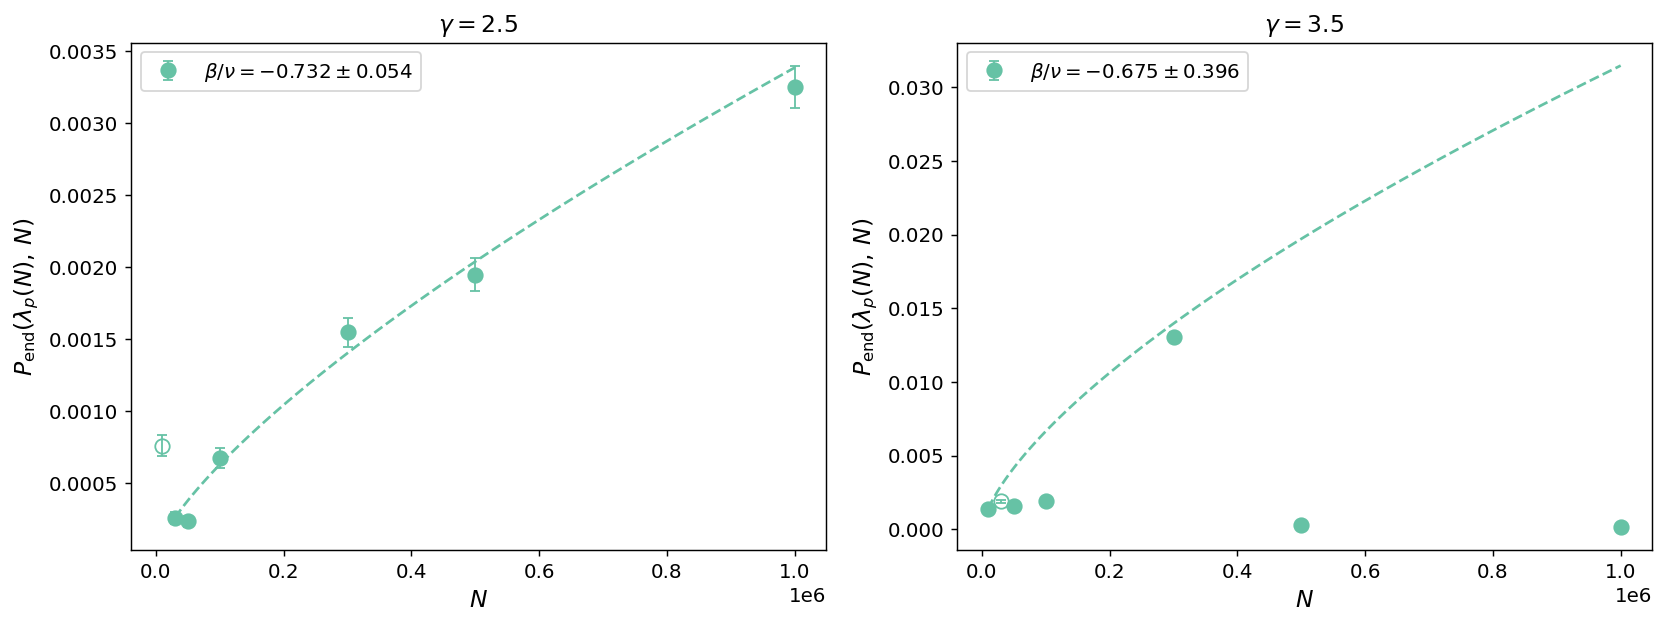

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
C1 = plt.cm.Set2(0)

masks = {
    2.5: (np.array(CFG["sizes"], float) >= 10000) & (np.array(CFG["sizes"], float) != 10000),
    3.5: (np.array(CFG["sizes"], float) >= 10000) & (np.array(CFG["sizes"], float) != 30000),
}

for g in CFG["gammas"]:
    Ns     = np.array(CFG["sizes"], float)
    Pc     = FIT[g]["Pc"]
    Pc_err = FIT[g]["Pc_err"]
    mask   = masks[g]
    slope, serr = powerlaw_slope(Ns[mask], Pc[mask], Pc_err[mask])
    FIT[g].update(beta_nu=-slope, beta_nu_err=serr)
    print(f"γ={g}:  β/ν={-slope:.4f}±{serr:.4f}")

for ax, g in zip(axes, CFG["gammas"]):
    Ns     = np.array(CFG["sizes"], float)
    Pc     = FIT[g]["Pc"]
    Pc_err = FIT[g]["Pc_err"]
    bnu    = FIT[g]["beta_nu"]
    berr   = FIT[g]["beta_nu_err"]
    mask   = masks[g]

    ax.errorbar(Ns[~mask], Pc[~mask], yerr=Pc_err[~mask],
                fmt='o', color=C1, ms=8, mfc='none', capsize=3, lw=1)
    ax.errorbar(Ns[mask], Pc[mask], yerr=Pc_err[mask],
                fmt='o', color=C1, ms=8, capsize=3, lw=1,
                label=fr"$\beta/\nu={bnu:.3f}\pm{berr:.3f}$")
    if np.isfinite(bnu):
        logA  = np.log(Pc[mask][0]) + bnu*np.log(Ns[mask][0])
        Nplot = np.logspace(np.log10(Ns[mask][0]), np.log10(Ns[mask][-1]), 100)
        ax.plot(Nplot, np.exp(logA - bnu*np.log(Nplot)),
                  '--', color=C1, lw=1.5)
    ax.set(xlabel="$N$", ylabel=r"$P_{\rm end}(\lambda_p(N),\,N)$",
           title=fr"$\gamma={g}$")
    ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("resultados_finales/ap5.pdf", bbox_inches='tight')
plt.show()

γ=2.5: usando lc_collapse=0.03293  (lc_fit=0.00140)


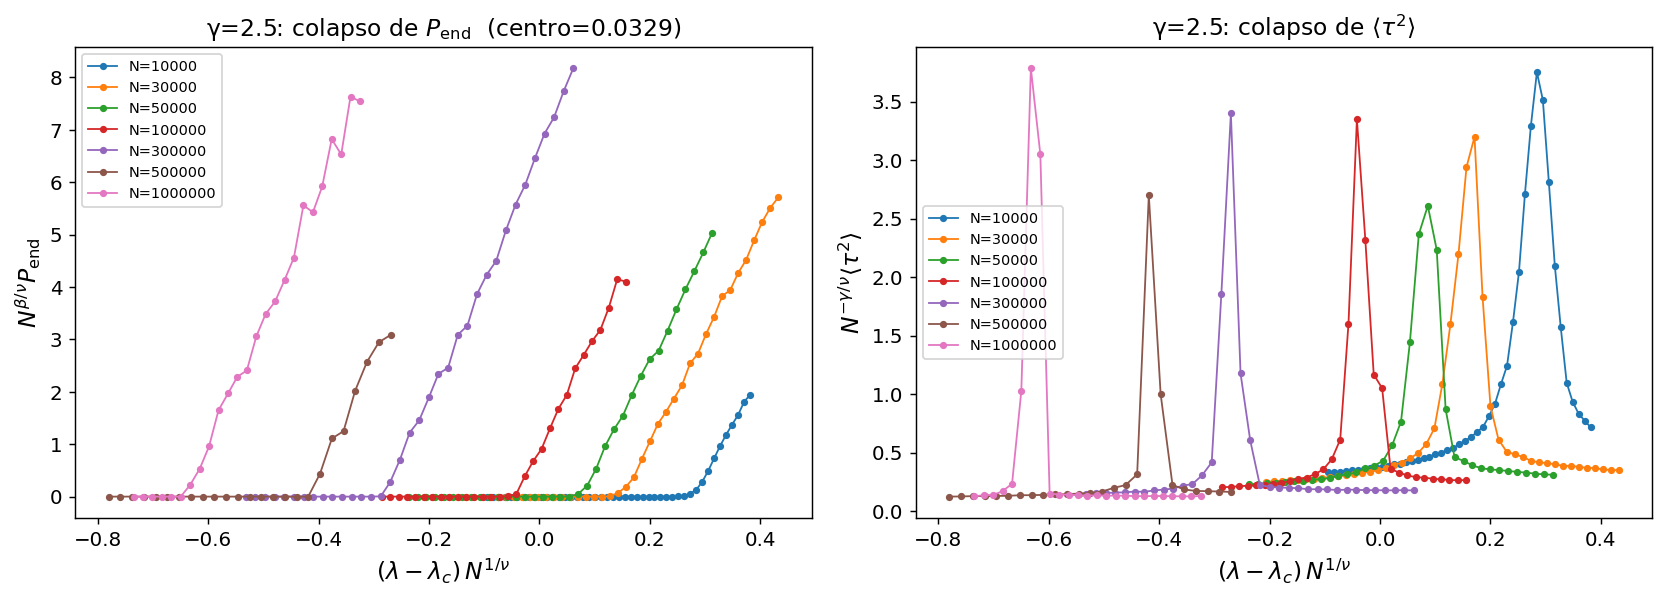

γ=3.5: usando lc_collapse=0.06666  (lc_fit=0.06666)


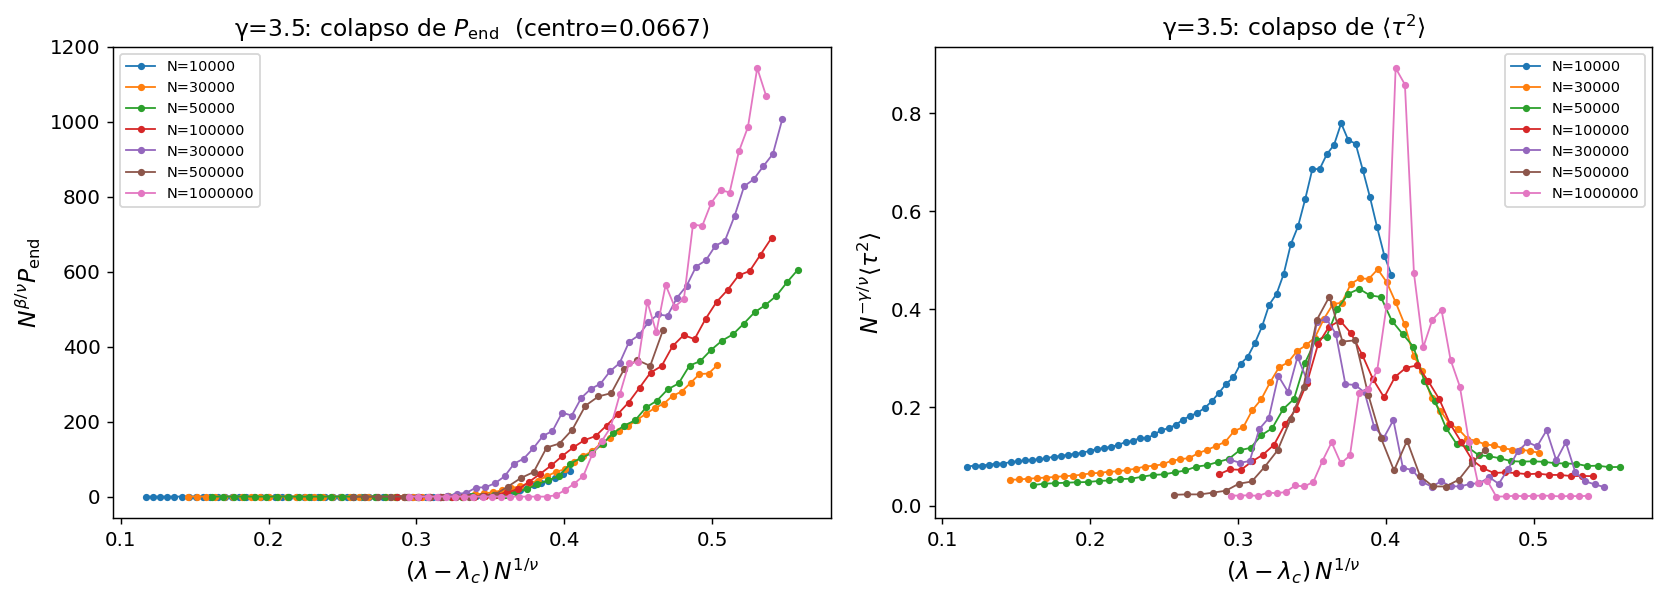

In [175]:
for g in CFG["gammas"]:
    p = FIT[g]; inv_nu, bnu = p["inv_nu"], p["beta_nu"]
    LP = p["LP"]
    
    lc_collapse = p["lc"] if p["lc"] > 0.5 * LP.min() else np.mean(LP)
    print(f"γ={g}: usando lc_collapse={lc_collapse:.5f}  (lc_fit={p['lc']:.5f})")

    use_tau2 = abs(p["g1_nu"]) < 0.1
    gn = p["g2_nu"] if use_tau2 else p["g1_nu"]
    ycol = "tau2_mean" if use_tau2 else "tau_mean"
    ylab = r"\langle\tau^2\rangle" if use_tau2 else r"\langle\tau\rangle"

    fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
    for N in CFG["sizes"]:
        d = RES[g][N]
        x  = (d['lambda'].values - lc_collapse) * N**inv_nu
        ax[0].plot(x, N**( bnu) * d['p_end'].values,  'o-', ms=3, lw=1, label=f"N={N}")
        ax[1].plot(x, N**(-gn)  * d[ycol].values,     'o-', ms=3, lw=1, label=f"N={N}")
    ax[0].set(xlabel=r"$(\lambda-\lambda_c)\,N^{1/\nu}$",
              ylabel=r"$N^{\beta/\nu}P_{\rm end}$",
              title=fr"γ={g}: colapso de $P_{{\rm end}}$  (centro={lc_collapse:.4f})")
    ax[1].set(xlabel=r"$(\lambda-\lambda_c)\,N^{1/\nu}$",
              ylabel=fr"$N^{{-\gamma/\nu}}{ylab}$",
              title=fr"γ={g}: colapso de ${ylab}$")
    for a in ax: a.legend(fontsize=8)
    plt.tight_layout(); plt.show()

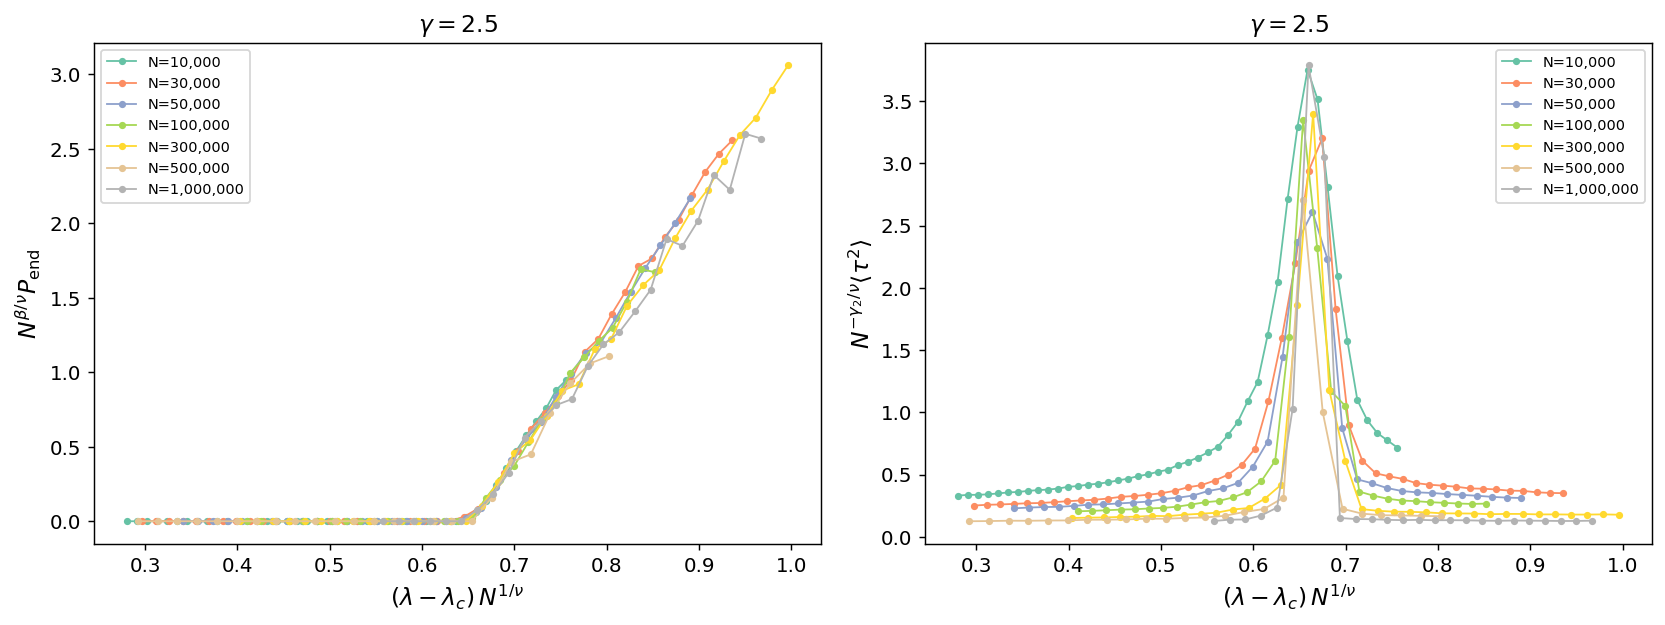

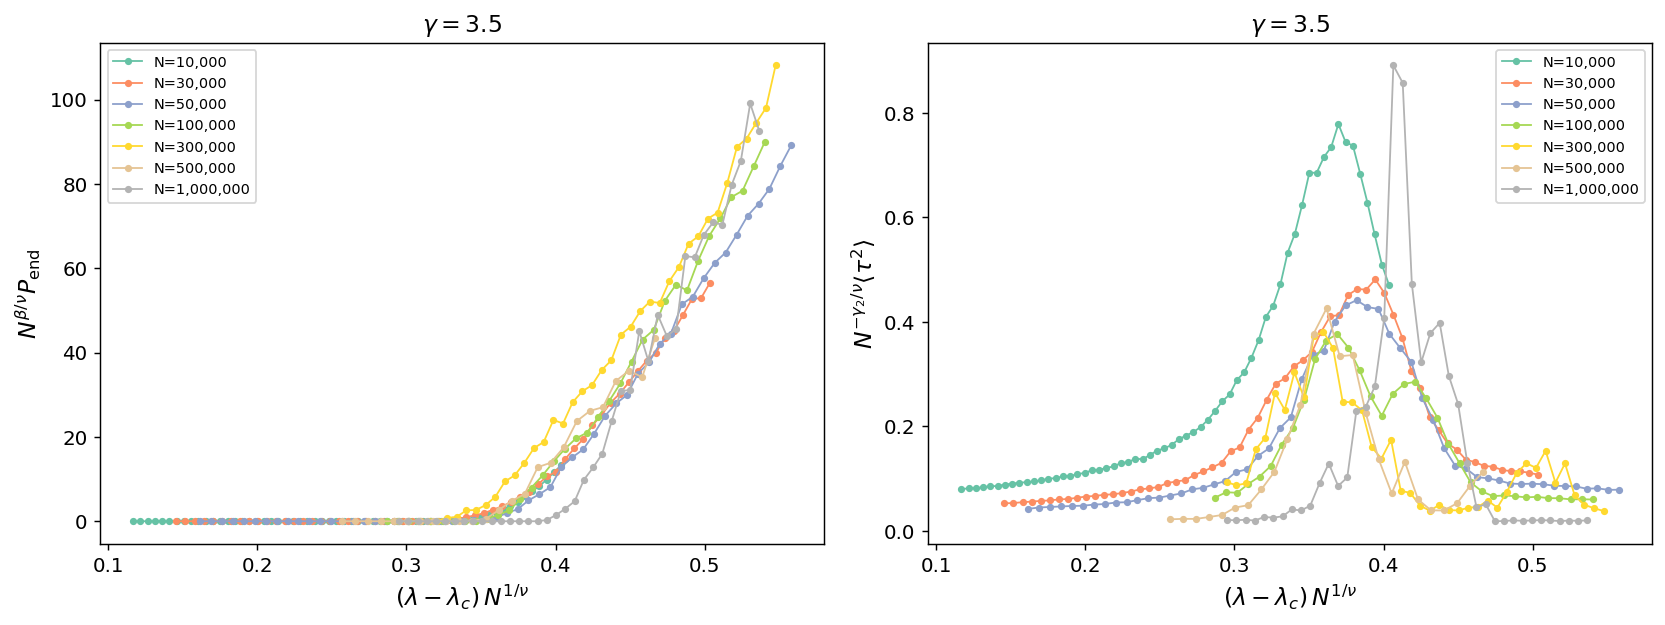

In [205]:
for g in CFG["gammas"]:
    p      = FIT[g]
    lc     = p["lc"]
    inv_nu = p["inv_nu"]
    bnu    = p["beta_nu"]
    gn     = p["g2_nu"]

    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    for N in CFG["sizes"]:
        d = RES[g][N]
        c = COLORS[N]
        x  = (d['lambda'].values - lc) * N**inv_nu

        m  = (x > -2) & (x < 5)
        ax[0].plot(x[m], N**( bnu) * d['p_end'].values[m],
                   'o-', ms=3, lw=1, color=c, label=f"N={N:,}")
        ax[1].plot(x[m], N**(-gn)  * d['tau2_mean'].values[m],
                   'o-', ms=3, lw=1, color=c, label=f"N={N:,}")

    ax[0].set(xlabel=r"$(\lambda-\lambda_c)\,N^{1/\nu}$",
              ylabel=r"$N^{\beta/\nu}P_{\rm end}$",
              title=fr"$\gamma={g}$")
    ax[1].set(xlabel=r"$(\lambda-\lambda_c)\,N^{1/\nu}$",
              ylabel=r"$N^{-\gamma_2/\nu}\langle\tau^2\rangle$",
              title=fr"$\gamma={g}$")
    for a in ax: a.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f"resultados_finales/ap6_g{str(g).replace('.','')}.pdf",
                bbox_inches='tight')
    plt.show()

In [41]:
for g in CFG["gammas"]:
    print(f"γ={g}:")
    print(f"  λc={FIT[g]['lc']:.5f}  1/ν={FIT[g]['inv_nu']:.4f}")
    print(f"  γ1/ν={FIT[g]['g1_nu']:.4f}  γ2/ν={FIT[g]['g2_nu']:.4f}")
    print(f"  β/ν={FIT[g]['beta_nu']:.4f}")
    print(f"  HP={np.round(FIT[g]['HP'],3)}")
    print(f"  HP2={np.round(FIT[g]['HP2'],1)}")
    print(f"  Pc={np.round(FIT[g]['Pc'],5)}")

γ=3.5:
  λc=0.03675  1/ν=0.1076
  γ1/ν=-0.0560  γ2/ν=0.1917
  β/ν=0.2946
  HP=[2.13  1.985 1.866 1.812 1.683 1.644 1.688]
  HP2=[ 48.9  57.2  56.9  56.3  51.8  76.2 171.3]
  Pc=[1.41e-03 1.67e-03 1.06e-03 1.72e-03 3.90e-04 1.60e-04 5.00e-05]


In [55]:
g = 3.5
Ns = np.array(CFG["sizes"], float)

mask = Ns >= 100_000
Ns_big  = Ns[mask]
HP2_big = FIT[g]["HP2"][mask]
Pc_big  = FIT[g]["Pc"][mask]

g2_nu_big, g2_err_big = powerlaw_slope(Ns_big, HP2_big)
bnu_big,   bnu_err    = powerlaw_slope(Ns_big, Pc_big)

print(f"γ2/ν (N≥100k) = {g2_nu_big:.4f} ± {g2_err_big:.4f}")
print(f"β/ν  (N≥100k) = {-bnu_big:.4f} ± {bnu_err:.4f}")

FIT[g].update(g2_nu=g2_nu_big, g2_nu_err=g2_err_big,
              beta_nu=-bnu_big, beta_nu_err=bnu_err)

γ2/ν (N≥100k) = -0.2118 ± 0.2815
β/ν  (N≥100k) = 0.1240 ± 0.9457


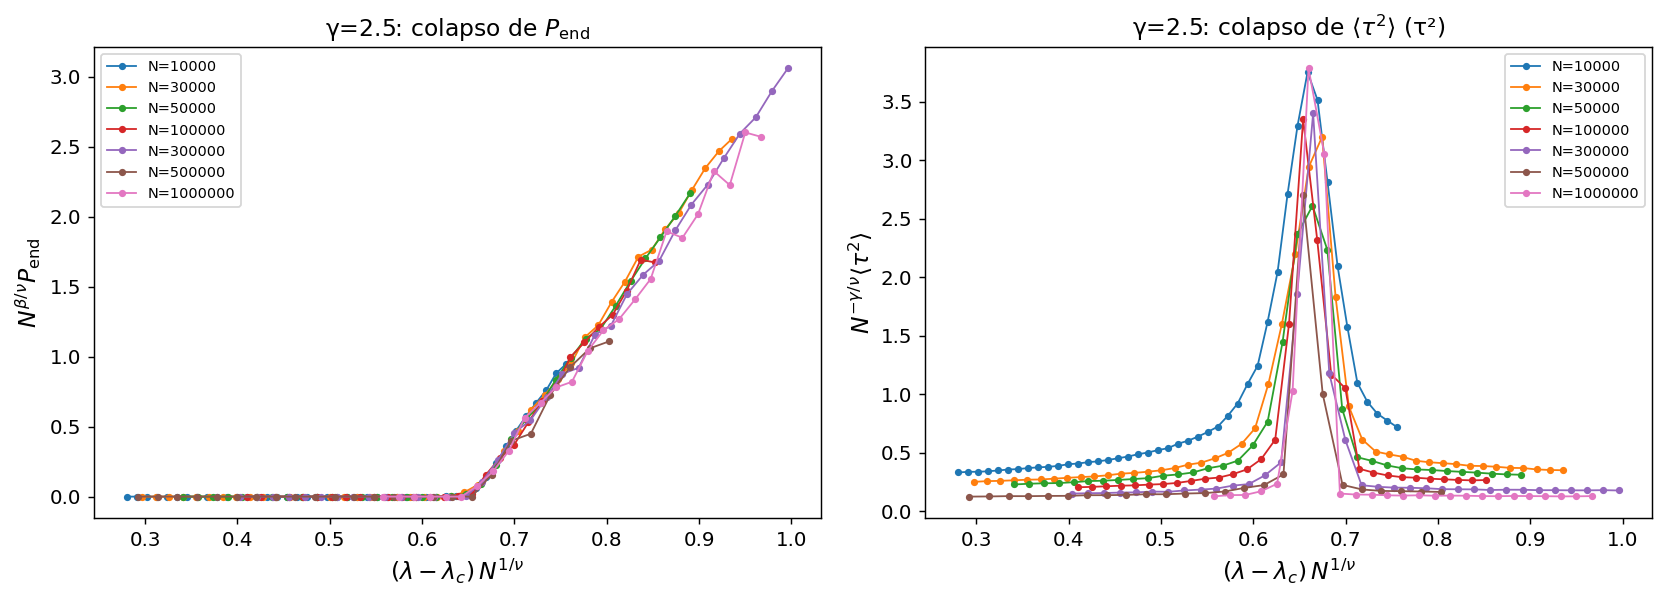

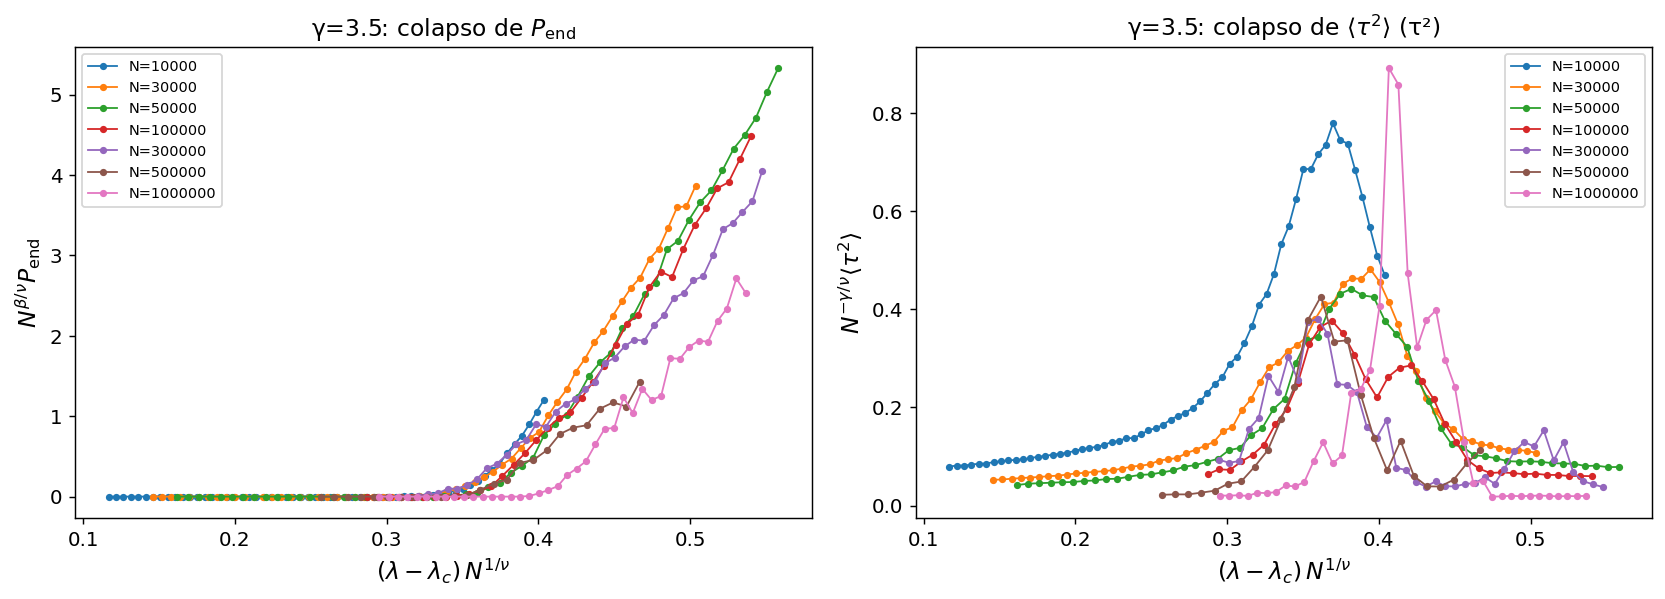

In [182]:
for g in CFG["gammas"]:
    p = FIT[g]; lc, inv_nu, bnu = p["lc"], p["inv_nu"], p["beta_nu"]

    use_tau2 = abs(p["g1_nu"]) < 0.1
    gn = p["g2_nu"] if use_tau2 else p["g1_nu"]
    ycol, ylab = ("tau2_mean", r"\langle\tau^2\rangle") if use_tau2 else ("tau_mean", r"\langle\tau\rangle")

    fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
    for N in CFG["sizes"]:
        d = RES[g][N]
        x  = (d['lambda'].values - lc)*N**inv_nu
        ax[0].plot(x, N**( bnu)*d['p_end'].values,    'o-', ms=3, lw=1, label=f"N={N}")
        ax[1].plot(x, N**(-gn) *d[ycol].values,       'o-', ms=3, lw=1, label=f"N={N}")
    ax[0].set(xlabel=r"$(\lambda-\lambda_c)\,N^{1/\nu}$",
              ylabel=r"$N^{\beta/\nu}P_{\rm end}$", title=fr"γ={g}: colapso de $P_{{\rm end}}$")
    ax[1].set(xlabel=r"$(\lambda-\lambda_c)\,N^{1/\nu}$",
              ylabel=fr"$N^{{-\gamma/\nu}}{ylab}$",
              title=fr"γ={g}: colapso de ${ylab}$ ({'τ²' if use_tau2 else 'τ'})")
    for a in ax: a.legend(fontsize=8)
    plt.tight_layout(); plt.show()

In [41]:
print(f"{'γ':>5} | {'λc':>10} | {'1/ν':>8} | {'β/ν':>10} | {'γ1/ν(<τ>)':>10} | {'γ2/ν(<τ²>)':>11}")
print("-"*70)
for g in CFG["gammas"]:
    p = FIT[g]
    print(f"{g:5} | {p['lc']:.5f} | {p['inv_nu']:7.3f} | {p['beta_nu']:9.3f} | "
          f"{p['g1_nu']:9.3f} | {p['g2_nu']:10.3f}")
print()
for g in CFG["gammas"]:
    d = RES[g][CFG['sizes'][-1]]
    print(f"γ={g}: red mayor → <k>={d['mean_k'].iloc[0]:.3f}, <k²>={d['mean_k2'].iloc[0]:.1f}, "
          f"λc_MF≈{d['mean_k'].iloc[0]/d['mean_k2'].iloc[0]:.4f}")

    γ |         λc |      1/ν |        β/ν |  γ1/ν(<τ>) |  γ2/ν(<τ²>)
----------------------------------------------------------------------
  3.5 | 0.08380 |   0.253 |       nan |    -0.072 |      0.096
  2.5 | 0.00174 |   0.272 |       nan |    -0.112 |     -0.406

γ=3.5: red mayor → <k>=5.910, <k²>=55.3, λc_MF≈0.1069
γ=2.5: red mayor → <k>=9.451, <k²>=309.4, λc_MF≈0.0305
